# Projeto 2 — Aprendizado de Máquina: Olist
**Disciplina:** T326 - Ciência dos Dados
**Professor:** Caio Ponte
**Turma:** 16/17

## Resumo
Este notebook implementa um **pipeline completo de Aprendizado de Máquina** sobre o dataset público da **Olist** (e-commerce brasileiro). O objetivo é **prever o tempo (em dias) que um pedido leva para chegar à casa do cliente**, a partir de características extraídas das tabelas de pedidos, itens, produtos, vendedores, clientes e geolocalização. O modelo principal usa o prazo estimado pela própria Olist como feature operacional, e a avaliação inclui uma ablação sem essa variável para deixar claro quanto ela contribui.

A estrutura segue as etapas do enunciado:
1. **Definição do Problema** — contexto Olist, problema de regressão, schema das tabelas.
2. **Pré-processamento dos Dados** — engenharia de atributos, limpeza, imputação, escalonamento e codificação.
3. **Análise Exploratória dos Dados (EDA)** — distribuições, outliers, correlações, descritivas, mapas geográficos.
4. **Análise da Utilidade das Features** *(extra)* — 6 métodos de feature importance + ranking consolidado.
5. **Treinamento do Modelo** — 4 modelos (Ridge, Decision Tree, Random Forest, HistGradientBoosting) com tuning via `GridSearchCV` / `RandomizedSearchCV` em validação cruzada de 5 folds.
6. **Avaliação e Conclusão** — RMSE/MAE/R², benchmark, diagnósticos visuais, melhorias e conclusão.

### Resultado final
**HistGradientBoosting** é o modelo vencedor com **RMSE = 5.87 dias**, **MAE = 4.16 dias** e **R² = 0.435** no conjunto de teste — superando o baseline ingênuo no teste em **1.94 dia de RMSE**.


In [1]:
# === Setup: Importação de Bibliotecas ===
# Esta célula carrega todas as bibliotecas usadas ao longo do notebook.
# Centralizar imports facilita a reprodutibilidade e a leitura.

import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer

# Modelos (Seção 5)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Seleção de modelo / tuning (Seção 5)
from sklearn.model_selection import (
    train_test_split, KFold, GridSearchCV, RandomizedSearchCV, cross_val_score,
)

# Métricas (Seção 6)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

try:
    from category_encoders import TargetEncoder
except ImportError:
    TargetEncoder = None  # fallback opcional; instalar via requirements.txt

# Configurações globais
warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


In [2]:
# === Setup: Configuração de Caminhos ===
# Define o diretório onde estão os CSVs do Olist (./dataset relativo à raiz do projeto)
# e valida que todos os arquivos esperados existem antes de prosseguir.

DATA_DIR = Path("./dataset")

ARQUIVOS_ESPERADOS = [
    "olist_customers_dataset.csv",
    "olist_geolocation_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_orders_dataset.csv",
    "olist_products_dataset.csv",
    "olist_sellers_dataset.csv",
    "product_category_name_translation.csv",
]

faltando = [f for f in ARQUIVOS_ESPERADOS if not (DATA_DIR / f).exists()]
if faltando:
    raise FileNotFoundError(
        f"Arquivos do dataset não encontrados em {DATA_DIR.resolve()}: {faltando}"
    )

print(f"Diretório de dados: {DATA_DIR.resolve()}")
print(f"Todos os {len(ARQUIVOS_ESPERADOS)} arquivos do Olist foram localizados.")


Diretório de dados: C:\Users\felip\olist-delivery-time-prediction-review\dataset
Todos os 9 arquivos do Olist foram localizados.


## 1. Definição do Problema (PDF Seção 1, Peso 10%)

### 🎯 O que este modelo prediz?

> **Saída do modelo:** um número contínuo — **a quantidade de dias** (com casas decimais) que um pedido vai levar entre o momento da **compra** e a **entrega na casa do cliente**.
>
> **Entrada do modelo:** características conhecidas no momento da compra/aprovação: UF do cliente e do vendedor, distância geográfica entre eles, valor do frete, peso/volume dos produtos, mês/dia da compra e, no modelo principal, o prazo estimado operacionalmente pela Olist.
>
> **Tipo de tarefa:** **regressão supervisionada** (saída numérica contínua, não classes).

**Exemplo concreto (ilustrativo):**

| Entrada (features do pedido) | Saída do modelo |
|---|---|
| `customer_state=CE`, `seller_state=SP`, `distância=2.300 km`, `frete=R$ 42,10`, `peso=850 g`, `mês=11` | `delivery_time_days ≈ 14,2 dias` |
| `customer_state=SP`, `seller_state=SP`, `distância=12 km`, `frete=R$ 9,90`, `peso=200 g`, `mês=4` | `delivery_time_days ≈ 3,7 dias` |

**Utilidade prática para a Olist:**
- Refinar, auditar e explicar a **janela de entrega estimada** já usada pela operação.
- **Sinalizar pedidos de risco** logo após a compra (quando a previsão fica muito acima da média).
- Identificar **rotas / UFs que cronicamente entregam tarde** e direcionar ações operacionais.

---

### Contexto da Olist
A **Olist** é um marketplace brasileiro que conecta pequenos e médios lojistas aos maiores e-commerces do país. Cada pedido envolve um cliente, um ou mais vendedores e operadores logísticos, o que torna o **tempo de entrega** uma métrica crítica para a satisfação do cliente e para o planejamento operacional.

### Problema de Regressão (formal)
- **Cada amostra** = um pedido entregue (uma linha por `order_id`).
- **Variável alvo** (contínua): `delivery_time_days` = dias entre `order_purchase_timestamp` e `order_delivered_customer_date`.
- **Tipo de problema:** regressão supervisionada.

### Tabelas utilizadas
- `olist_orders_dataset` — pedidos e timestamps (núcleo do dataset).
- `olist_customers_dataset` — localização do cliente.
- `olist_order_items_dataset` — itens, frete, vendedor.
- `olist_products_dataset` — categoria, peso, dimensões dos produtos.
- `olist_sellers_dataset` — localização do vendedor.
- `olist_geolocation_dataset` — coordenadas (latitude/longitude) por CEP.

Tabelas de pagamento e reviews não são essenciais para a tarefa de **previsão de tempo de entrega** e, portanto, são deixadas de fora do conjunto final.

### Desafio e Impacto
Estimar o tempo de entrega permite **definir prazos realistas para o cliente**, **identificar gargalos logísticos** e **comparar/calibrar a previsão em relação ao prazo estimado pela própria Olist** (`order_estimated_delivery_date`), apoiando decisões de negócio. Como essa coluna é uma estimativa operacional do mesmo fenômeno, ela é tratada explicitamente como feature sensível e avaliada também por ablação.


In [3]:
# === Seção 1 — Carregamento das Tabelas Brutas (PDF p.2: identificação das tabelas) ===
# Lê todos os 9 CSVs do Olist em um dicionário para facilitar a inspeção e os merges posteriores.

tabelas = {
    "orders":      pd.read_csv(DATA_DIR / "olist_orders_dataset.csv"),
    "customers":   pd.read_csv(DATA_DIR / "olist_customers_dataset.csv"),
    "order_items": pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv"),
    "products":    pd.read_csv(DATA_DIR / "olist_products_dataset.csv"),
    "sellers":     pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv"),
    "geolocation": pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv"),
    "payments":    pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv"),
    "reviews":     pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv"),
    "categoria":   pd.read_csv(DATA_DIR / "product_category_name_translation.csv"),
}

print("Dimensões das tabelas carregadas:")
for nome, df_ in tabelas.items():
    print(f"  {nome:12s} -> {df_.shape}")


Dimensões das tabelas carregadas:
  orders       -> (99441, 8)
  customers    -> (99441, 5)
  order_items  -> (112650, 7)
  products     -> (32951, 9)
  sellers      -> (3095, 4)
  geolocation  -> (1000163, 5)
  payments     -> (103886, 5)
  reviews      -> (99224, 7)
  categoria    -> (71, 2)


In [4]:
# === Seção 1 — Visão geral do Schema ===
# Para cada tabela, exibe colunas e tipos. Isso confirma quais colunas estão disponíveis
# para engenharia de atributos e identificar campos de timestamp para conversão.

for nome, df_ in tabelas.items():
    print(f"\n=== {nome} ===")
    print(df_.dtypes)



=== orders ===
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

=== customers ===
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

=== order_items ===
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

=== products ===
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_wei

### Relacionamento entre tabelas

```
customers (customer_id)  ─┐
                          ├──> orders (order_id) ──> order_items ──> products
sellers   (seller_id)  ───┘                                ↑
                                                           │
geolocation (zip_code_prefix)  attaches lat/lng to customers e sellers
```

**Justificativa da escolha:**
- `orders` traz os timestamps que definem a variável alvo.
- `order_items` permite agregar quantidade de itens, preço total e frete por pedido.
- `products` adiciona características físicas (peso/volume) que afetam o frete.
- `customers` + `sellers` + `geolocation` permitem calcular a **distância geográfica** cliente↔vendedor, fortemente correlacionada com o tempo de entrega.


## 2. Pré-processamento dos Dados (PDF Seção 2, Peso 30%)

Cobrimos **todos os 5 sub-requisitos** do PDF (rubrica exige ao menos 4):
1. Engenharia de atributos
2. Filtragem e limpeza
3. Tratamento de valores faltantes
4. Normalização / padronização
5. Tratamento de variáveis categóricas


In [5]:
# === Seção 2.1 — Filtragem: manter apenas pedidos entregues (PDF p.2: limpeza) ===
# A variável alvo só faz sentido para pedidos entregues. Removemos status diferentes
# e linhas sem timestamp de entrega ao cliente.

orders = tabelas["orders"].copy()
print(f"Antes da filtragem: {orders.shape}")

orders = orders[orders["order_status"] == "delivered"].copy()
orders = orders.dropna(subset=["order_delivered_customer_date", "order_purchase_timestamp"])

print(f"Após filtrar entregues e timestamps válidos: {orders.shape}")


Antes da filtragem: (99441, 8)
Após filtrar entregues e timestamps válidos: (96470, 8)


In [6]:
# === Seção 2.1 — Conversão de Datas ===
# Converte todas as colunas temporais para datetime para permitir cálculos de diferença.

colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for c in colunas_data:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

print(orders[colunas_data].dtypes)


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [7]:
# === Seção 2.1 — Construção da Variável Alvo ===
# delivery_time_days = (entrega ao cliente) - (compra), em dias (float).
# Removemos valores patológicos (negativos ou zero) que indicam erro de registro.

orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400.0

antes = len(orders)
orders = orders[orders["delivery_time_days"] > 0].copy()
print(f"Linhas removidas com tempo <= 0: {antes - len(orders)}")
print(orders["delivery_time_days"].describe())


Linhas removidas com tempo <= 0: 0
count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_time_days, dtype: float64


In [8]:
# === Seção 2.1 — Engenharia de Atributos: Nível Pedido (PDF p.2: feature engineering) ===
# Variáveis temporais derivadas da data de compra e da data estimada pela Olist.

orders["purchase_dow"]   = orders["order_purchase_timestamp"].dt.dayofweek      # 0 = segunda
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.month
orders["purchase_hour"]  = orders["order_purchase_timestamp"].dt.hour

orders["estimated_delivery_days"] = (
    orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400.0

orders["approval_delay_hours"] = (
    orders["order_approved_at"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 3600.0

print(orders[["purchase_dow", "purchase_month", "purchase_hour",
              "estimated_delivery_days", "approval_delay_hours"]].head())


   purchase_dow  purchase_month  purchase_hour  estimated_delivery_days  approval_delay_hours
0             0              10             10                15.544063              0.178333
1             1               7             20                19.137766             30.713889
2             2               8              8                26.639711              0.276111
3             5              11             19                26.188819              0.298056
4             1               2             21                12.112049              1.030556


In [9]:
# === Seção 2.1 — Engenharia de Atributos: Agregação de Itens ===
# Cada pedido pode ter múltiplos itens. Agregamos por order_id para uma única linha por pedido.

itens = tabelas["order_items"].copy()

agg_itens = itens.groupby("order_id").agg(
    n_items       = ("order_item_id", "count"),
    n_sellers     = ("seller_id", "nunique"),
    total_price   = ("price", "sum"),
    total_freight = ("freight_value", "sum"),
).reset_index()

agg_itens["freight_ratio"] = (
    agg_itens["total_freight"] / agg_itens["total_price"].replace(0, np.nan)
)

print(agg_itens.head())
print(f"Linhas: {len(agg_itens)}")


                           order_id  n_items  n_sellers  total_price  total_freight  freight_ratio
0  00010242fe8c5a6d1ba2dd792cb16214        1          1        58.90          13.29       0.225637
1  00018f77f2f0320c557190d7a144bdd3        1          1       239.90          19.93       0.083076
2  000229ec398224ef6ca0657da4fc703e        1          1       199.00          17.87       0.089799
3  00024acbcdf0a6daa1e931b038114c75        1          1        12.99          12.79       0.984604
4  00042b26cf59d7ce69dfabb4e55b4fd9        1          1       199.90          18.14       0.090745
Linhas: 98666


In [10]:
# === Seção 2.1 — Engenharia de Atributos: Informações de Produto ===
# Junta dados de produto a cada item e agrega métricas físicas/categoria por pedido.

produtos = tabelas["products"].copy()
produtos["product_volume_cm3"] = (
    produtos["product_length_cm"]
    * produtos["product_height_cm"]
    * produtos["product_width_cm"]
)

itens_prod = itens.merge(
    produtos[[
        "product_id", "product_category_name", "product_weight_g",
        "product_volume_cm3", "product_photos_qty",
        "product_name_lenght", "product_description_lenght",
    ]],
    on="product_id", how="left",
)

agg_prod = itens_prod.groupby("order_id").agg(
    max_product_weight   = ("product_weight_g", "max"),
    total_product_volume = ("product_volume_cm3", "sum"),
    avg_photos_qty       = ("product_photos_qty", "mean"),
    avg_name_length      = ("product_name_lenght", "mean"),
    avg_desc_length      = ("product_description_lenght", "mean"),
    # Para a categoria, pegamos a categoria do primeiro item (proxy razoável)
    product_category     = ("product_category_name", "first"),
).reset_index()

print(agg_prod.head())


                           order_id  max_product_weight  total_product_volume  avg_photos_qty  avg_name_length  avg_desc_length    product_category
0  00010242fe8c5a6d1ba2dd792cb16214               650.0                3528.0             4.0             58.0            598.0          cool_stuff
1  00018f77f2f0320c557190d7a144bdd3             30000.0               60000.0             2.0             56.0            239.0            pet_shop
2  000229ec398224ef6ca0657da4fc703e              3050.0               14157.0             2.0             59.0            695.0    moveis_decoracao
3  00024acbcdf0a6daa1e931b038114c75               200.0                2400.0             1.0             42.0            480.0          perfumaria
4  00042b26cf59d7ce69dfabb4e55b4fd9              3750.0               42000.0             1.0             59.0            409.0  ferramentas_jardim


In [11]:
# === Seção 2.1 — Engenharia de Atributos: Geolocalização ===
# Calcula lat/lng médias por prefixo de CEP, anexa coordenadas a clientes e vendedores
# e calcula a distância Haversine cliente <-> vendedor (forte preditor de tempo de entrega).

geo = tabelas["geolocation"].copy()
geo_agg = geo.groupby("geolocation_zip_code_prefix").agg(
    lat=("geolocation_lat", "mean"),
    lng=("geolocation_lng", "mean"),
).reset_index().rename(columns={"geolocation_zip_code_prefix": "zip_prefix"})

# Coordenadas dos clientes
customers = tabelas["customers"][["customer_id", "customer_zip_code_prefix", "customer_state"]].copy()
customers = customers.merge(
    geo_agg.rename(columns={"zip_prefix": "customer_zip_code_prefix",
                             "lat": "customer_lat", "lng": "customer_lng"}),
    on="customer_zip_code_prefix", how="left",
)

# Coordenadas dos vendedores (pegamos o primeiro vendedor de cada pedido)
sellers = tabelas["sellers"][["seller_id", "seller_zip_code_prefix", "seller_state"]].copy()
sellers = sellers.merge(
    geo_agg.rename(columns={"zip_prefix": "seller_zip_code_prefix",
                             "lat": "seller_lat", "lng": "seller_lng"}),
    on="seller_zip_code_prefix", how="left",
)
primeiro_seller = itens.sort_values("order_item_id").drop_duplicates("order_id")[["order_id", "seller_id"]]
seller_por_pedido = primeiro_seller.merge(sellers, on="seller_id", how="left")


def haversine_km(lat1, lon1, lat2, lon2):
    """Distância em quilômetros entre dois pontos (lat, lng) na superfície da Terra."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


print("Geolocalização preparada. Distância será calculada após o merge final.")


Geolocalização preparada. Distância será calculada após o merge final.


In [12]:
# === Seção 2.1 — Master Merge ===
# Junta orders + customers + agregação de itens + agregação de produtos + geolocalização
# em um único DataFrame plano (uma linha por pedido).

df = (
    orders[[
        "order_id", "customer_id", "delivery_time_days",
        "purchase_dow", "purchase_month", "purchase_hour",
        "estimated_delivery_days", "approval_delay_hours",
    ]]
    .merge(customers, on="customer_id", how="left")
    .merge(agg_itens, on="order_id", how="left")
    .merge(agg_prod, on="order_id", how="left")
    .merge(seller_por_pedido[["order_id", "seller_state", "seller_lat", "seller_lng"]],
           on="order_id", how="left")
)

# Distância Haversine cliente <-> vendedor
df["customer_seller_distance_km"] = haversine_km(
    df["customer_lat"], df["customer_lng"], df["seller_lat"], df["seller_lng"]
)

print(f"Shape final do DataFrame: {df.shape}")
print(f"Colunas: {list(df.columns)}")


Shape final do DataFrame: (96470, 27)
Colunas: ['order_id', 'customer_id', 'delivery_time_days', 'purchase_dow', 'purchase_month', 'purchase_hour', 'estimated_delivery_days', 'approval_delay_hours', 'customer_zip_code_prefix', 'customer_state', 'customer_lat', 'customer_lng', 'n_items', 'n_sellers', 'total_price', 'total_freight', 'freight_ratio', 'max_product_weight', 'total_product_volume', 'avg_photos_qty', 'avg_name_length', 'avg_desc_length', 'product_category', 'seller_state', 'seller_lat', 'seller_lng', 'customer_seller_distance_km']


In [13]:
# === Seção 2.2 — Filtragem de Outliers / Ruído (PDF p.2: limpeza) ===
# Tempos de entrega extremamente longos (> 99º percentil) provavelmente indicam casos
# atípicos (greve, devolução, registro tardio) e prejudicariam o aprendizado.

q99 = df["delivery_time_days"].quantile(0.99)
print(f"99º percentil do tempo de entrega: {q99:.1f} dias")

antes = len(df)
df = df[df["delivery_time_days"] <= q99].copy()
print(f"Linhas removidas (cap em 99º percentil): {antes - len(df)}")
print(f"Shape após corte de outliers: {df.shape}")


99º percentil do tempo de entrega: 46.1 dias
Linhas removidas (cap em 99º percentil): 965
Shape após corte de outliers: (95505, 27)


In [14]:
# === Seção 2.3 — Tratamento de Valores Faltantes (PDF p.2: SimpleImputer / KNNImputer) ===
# Diagnóstico antes de imputar: quanto cada coluna possui de valores nulos?

faltantes = df.isna().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
print("Valores faltantes por coluna:")
print(faltantes)

# Estratégia adotada (a imputação numérica de fato é feita pelo ColumnTransformer mais adiante):
# - Numéricas -> SimpleImputer(strategy='median'), robusto a assimetria e outliers.
# - Categóricas -> SimpleImputer(strategy='most_frequent').
# - Demonstração: KNNImputer aplicado a uma amostra para ilustrar a técnica alternativa.

amostra_numerica = df.select_dtypes(include="number").drop(columns=["delivery_time_days"]).head(2000)
demo_knn = KNNImputer(n_neighbors=5).fit_transform(amostra_numerica)
print(f"\nKNNImputer demonstrado em amostra de shape {amostra_numerica.shape} -> saída {demo_knn.shape}")
print("A imputação final será aplicada via ColumnTransformer (Seção 2.6).")


Valores faltantes por coluna:
avg_name_length                1324
avg_desc_length                1324
product_category               1324
avg_photos_qty                 1324
customer_seller_distance_km     469
customer_lng                    257
customer_lat                    257
seller_lng                      213
seller_lat                      213
max_product_weight               16
approval_delay_hours             14
dtype: int64

KNNImputer demonstrado em amostra de shape (2000, 21) -> saída (2000, 21)
A imputação final será aplicada via ColumnTransformer (Seção 2.6).


In [15]:
# === Seção 2.4 — Tratamento de Variáveis Categóricas (PDF p.2: OneHot / Target Encoder) ===
# Lista de colunas categóricas e estratégia por cardinalidade.

colunas_categoricas = ["customer_state", "seller_state", "product_category"]

for c in colunas_categoricas:
    print(f"{c}: cardinalidade = {df[c].nunique()}")

# Estratégia adotada:
# - customer_state / seller_state / product_category -> OneHotEncoder com handle_unknown="ignore".
# - TargetEncoder fica como melhoria futura para product_category, pois reduziria 73 categorias
#   para uma variável contínua, mas exigiria validação cuidadosa contra vazamento de alvo.
# A montagem é feita no ColumnTransformer (Seção 2.6) para evitar vazamento de dados.


customer_state: cardinalidade = 27
seller_state: cardinalidade = 22
product_category: cardinalidade = 73


In [16]:
# === Seção 2.5 — Normalização / Padronização (PDF p.2: RobustScaler / Log) ===
# Variáveis monetárias e de distância são tipicamente assimétricas (cauda longa).
# Aplicamos log1p (FunctionTransformer) e depois RobustScaler para neutralizar outliers.

colunas_log = ["total_price", "total_freight", "customer_seller_distance_km",
               "max_product_weight", "total_product_volume"]
colunas_numericas_padrao = [
    "purchase_dow", "purchase_month", "purchase_hour",
    "estimated_delivery_days", "approval_delay_hours",
    "n_items", "n_sellers", "freight_ratio",
    "avg_photos_qty", "avg_name_length", "avg_desc_length",
]

print(f"Colunas com log1p + RobustScaler: {colunas_log}")
print(f"Colunas com apenas RobustScaler: {colunas_numericas_padrao}")


Colunas com log1p + RobustScaler: ['total_price', 'total_freight', 'customer_seller_distance_km', 'max_product_weight', 'total_product_volume']
Colunas com apenas RobustScaler: ['purchase_dow', 'purchase_month', 'purchase_hour', 'estimated_delivery_days', 'approval_delay_hours', 'n_items', 'n_sellers', 'freight_ratio', 'avg_photos_qty', 'avg_name_length', 'avg_desc_length']


In [17]:
# === Seção 2.6 — Construção do ColumnTransformer ===
# Reúne imputação + escala + codificação em um único objeto reutilizável.
# Encaixar tudo em um Pipeline impede vazamento de dados entre treino e teste.

pipe_log = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log",     FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler",  RobustScaler()),
])

pipe_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("log", pipe_log, colunas_log),
        ("num", pipe_num, colunas_numericas_padrao),
        ("cat", pipe_cat, colunas_categoricas),
    ],
    remainder="drop",
)

print("ColumnTransformer construído com 3 ramos: log, num, cat.")


ColumnTransformer construído com 3 ramos: log, num, cat.


In [18]:
# === Seção 2.7 — Resumo das Features Selecionadas (PDF p.2: REQUERIDO) ===
# Tabela explicativa de todas as features e como cada uma é tratada.

resumo_features = pd.DataFrame([
    # Numéricas com log1p
    ("total_price",                "numérica", "log1p + RobustScaler", "Valor total dos itens do pedido"),
    ("total_freight",              "numérica", "log1p + RobustScaler", "Valor total do frete"),
    ("customer_seller_distance_km","numérica", "log1p + RobustScaler", "Distância Haversine cliente-vendedor"),
    ("max_product_weight",         "numérica", "log1p + RobustScaler", "Peso máximo entre os produtos do pedido"),
    ("total_product_volume",       "numérica", "log1p + RobustScaler", "Volume total dos produtos do pedido"),
    # Numéricas padrão
    ("purchase_dow",          "numérica", "RobustScaler", "Dia da semana da compra"),
    ("purchase_month",        "numérica", "RobustScaler", "Mês da compra"),
    ("purchase_hour",         "numérica", "RobustScaler", "Hora da compra"),
    ("estimated_delivery_days","numérica","RobustScaler", "Prazo estimado pela Olist em dias"),
    ("approval_delay_hours",  "numérica", "RobustScaler", "Horas entre compra e aprovação"),
    ("n_items",               "numérica", "RobustScaler", "Quantidade de itens no pedido"),
    ("n_sellers",             "numérica", "RobustScaler", "Vendedores únicos no pedido"),
    ("freight_ratio",         "numérica", "RobustScaler", "Frete dividido pelo preço total"),
    ("avg_photos_qty",        "numérica", "RobustScaler", "Média de fotos por produto"),
    ("avg_name_length",       "numérica", "RobustScaler", "Tamanho médio do nome do produto"),
    ("avg_desc_length",       "numérica", "RobustScaler", "Tamanho médio da descrição do produto"),
    # Categóricas
    ("customer_state",   "categórica", "OneHotEncoder", "UF do cliente"),
    ("seller_state",     "categórica", "OneHotEncoder", "UF do vendedor"),
    ("product_category", "categórica", "OneHotEncoder", "Categoria do primeiro produto"),
], columns=["feature", "tipo", "transformação", "descrição"])

print(resumo_features.to_string(index=False))
print(f"\nTotal de features: {len(resumo_features)}")
df.describe(include='all').T.head(40)


                    feature       tipo        transformação                               descrição
                total_price   numérica log1p + RobustScaler         Valor total dos itens do pedido
              total_freight   numérica log1p + RobustScaler                    Valor total do frete
customer_seller_distance_km   numérica log1p + RobustScaler    Distância Haversine cliente-vendedor
         max_product_weight   numérica log1p + RobustScaler Peso máximo entre os produtos do pedido
       total_product_volume   numérica log1p + RobustScaler     Volume total dos produtos do pedido
               purchase_dow   numérica         RobustScaler                 Dia da semana da compra
             purchase_month   numérica         RobustScaler                           Mês da compra
              purchase_hour   numérica         RobustScaler                          Hora da compra
    estimated_delivery_days   numérica         RobustScaler       Prazo estimado pela Olist em dias


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,95505,95505,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,95505,95505,9ef432eb6251297304e76186b10a928d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_time_days,95505.0,NaN,NaN,NaN,12.052942,7.740056,0.533414,6.722731,10.154329,15.369306,46.048461
purchase_dow,95505.0,NaN,NaN,NaN,2.755405,1.967444,0.0,1.0,3.0,4.0,6.0
purchase_month,95505.0,NaN,NaN,NaN,6.038689,3.220605,1.0,3.0,6.0,8.0,12.0
purchase_hour,95505.0,NaN,NaN,NaN,14.773959,5.32606,0.0,11.0,15.0,19.0,23.0
estimated_delivery_days,95505.0,NaN,NaN,NaN,23.66893,8.70821,2.008009,18.291933,23.196458,28.371655,155.135463
approval_delay_hours,95491.0,NaN,NaN,NaN,10.257906,20.400063,0.0,0.215278,0.343056,14.474028,741.443611
customer_zip_code_prefix,95505.0,NaN,NaN,NaN,35118.328433,29874.003411,1003.0,11088.0,24350.0,58920.0,99980.0
customer_state,95505,27,SP,40377,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Análise Exploratória dos Dados — EDA (PDF Seção 3, Peso 10%)

Cobrimos **todos os 5 sub-requisitos**: distribuições, outliers, correlações, estatísticas descritivas e mapas geográficos.


In [19]:
# === Seção 3.1 — Estatísticas Descritivas (PDF p.3) ===
# Resumo estatístico para colunas numéricas e contagens para categóricas.

print("=== Numéricas ===")
print(df.describe().T)

print("\n=== Categóricas ===")
print(df.describe(include='object').T)


=== Numéricas ===
                               count          mean           std          min           25%           50%           75%           max
delivery_time_days           95505.0     12.052942      7.740056     0.533414      6.722731     10.154329     15.369306  4.604846e+01
purchase_dow                 95505.0      2.755405      1.967444     0.000000      1.000000      3.000000      4.000000  6.000000e+00
purchase_month               95505.0      6.038689      3.220605     1.000000      3.000000      6.000000      8.000000  1.200000e+01
purchase_hour                95505.0     14.773959      5.326060     0.000000     11.000000     15.000000     19.000000  2.300000e+01
estimated_delivery_days      95505.0     23.668930      8.708210     2.008009     18.291933     23.196458     28.371655  1.551355e+02
approval_delay_hours         95491.0     10.257906     20.400063     0.000000      0.215278      0.343056     14.474028  7.414436e+02
customer_zip_code_prefix     95505.0  35118.

                  count unique                               top   freq
order_id          95505  95505  e481f51cbdc54678b7cc49136f2d6af7      1
customer_id       95505  95505  9ef432eb6251297304e76186b10a928d      1
customer_state    95505     27                                SP  40377
product_category  94181     73                   cama_mesa_banho   9064
seller_state      95505     22                                SP  67742


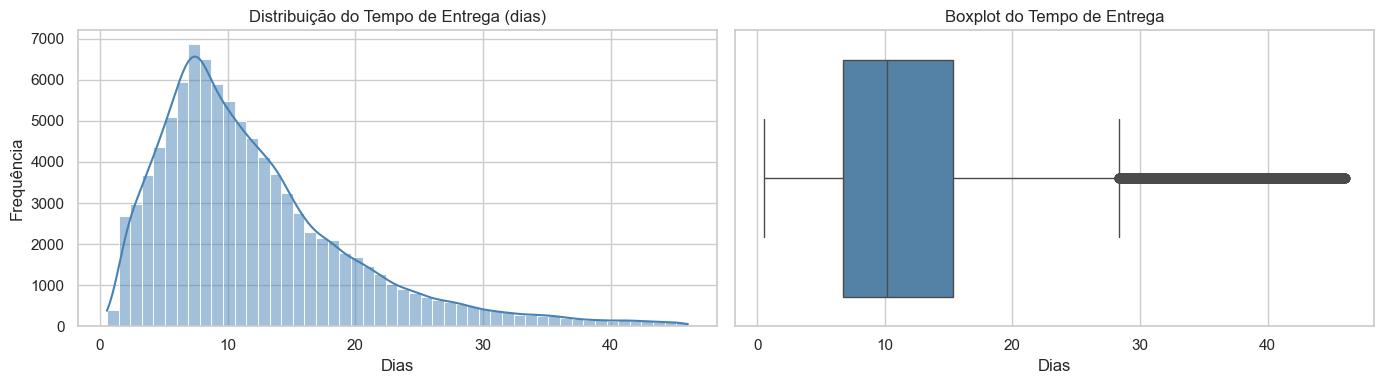

Média: 12.05 dias
Mediana: 10.15 dias
Desvio padrão: 7.74 dias


In [20]:
# === Seção 3.2 — Distribuição da Variável Alvo (PDF p.3) ===
# Histograma + boxplot para entender a assimetria do tempo de entrega.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["delivery_time_days"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribuição do Tempo de Entrega (dias)")
axes[0].set_xlabel("Dias")
axes[0].set_ylabel("Frequência")

sns.boxplot(x=df["delivery_time_days"], ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot do Tempo de Entrega")
axes[1].set_xlabel("Dias")

plt.tight_layout()
plt.show()

print(f"Média: {df['delivery_time_days'].mean():.2f} dias")
print(f"Mediana: {df['delivery_time_days'].median():.2f} dias")
print(f"Desvio padrão: {df['delivery_time_days'].std():.2f} dias")


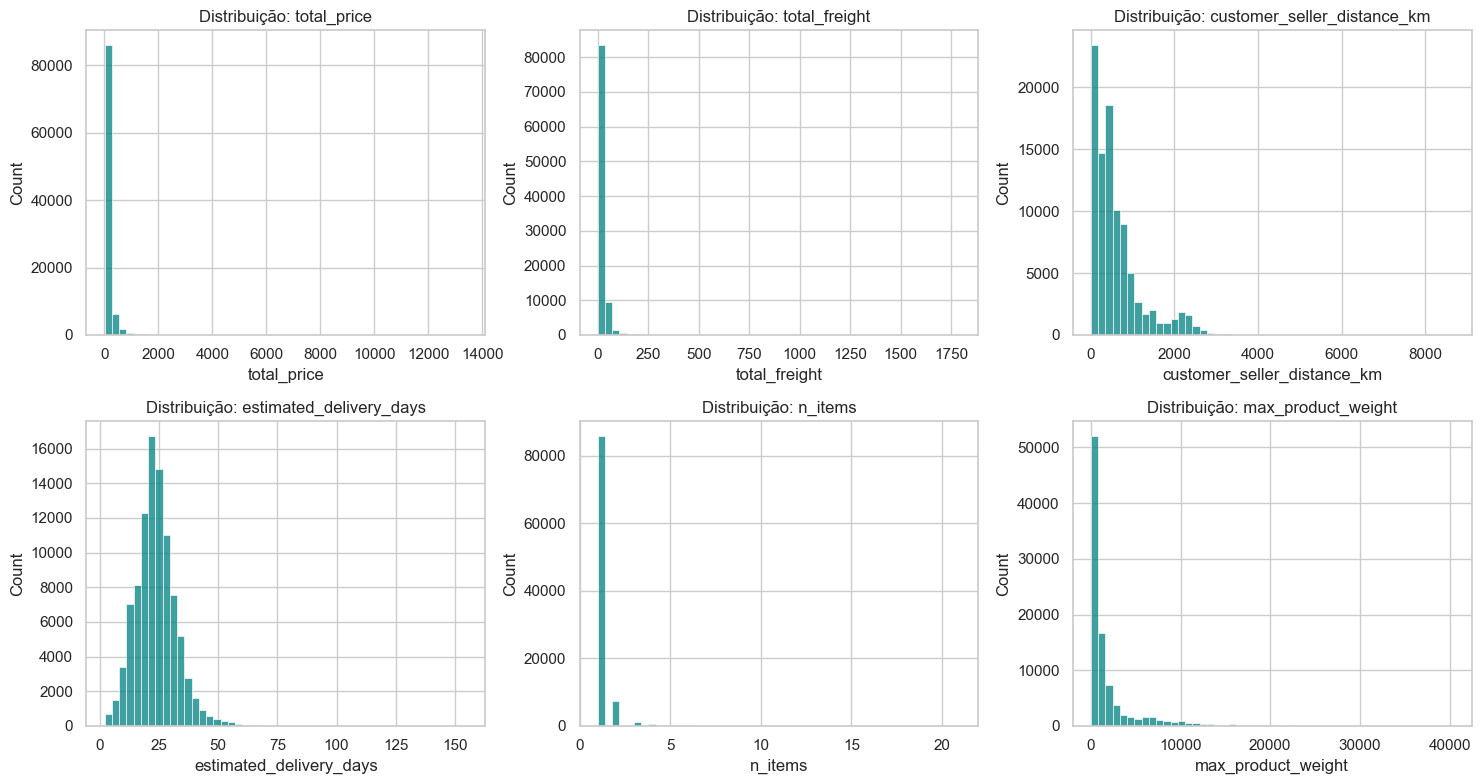

In [21]:
# === Seção 3.2 — Distribuição das Features Numéricas ===
# Grade de histogramas para inspecionar assimetria e necessidade de transformações.

features_plot = [
    "total_price", "total_freight", "customer_seller_distance_km",
    "estimated_delivery_days", "n_items", "max_product_weight",
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, features_plot):
    sns.histplot(df[col].dropna(), bins=50, ax=ax, color="teal")
    ax.set_title(f"Distribuição: {col}")
plt.tight_layout()
plt.show()


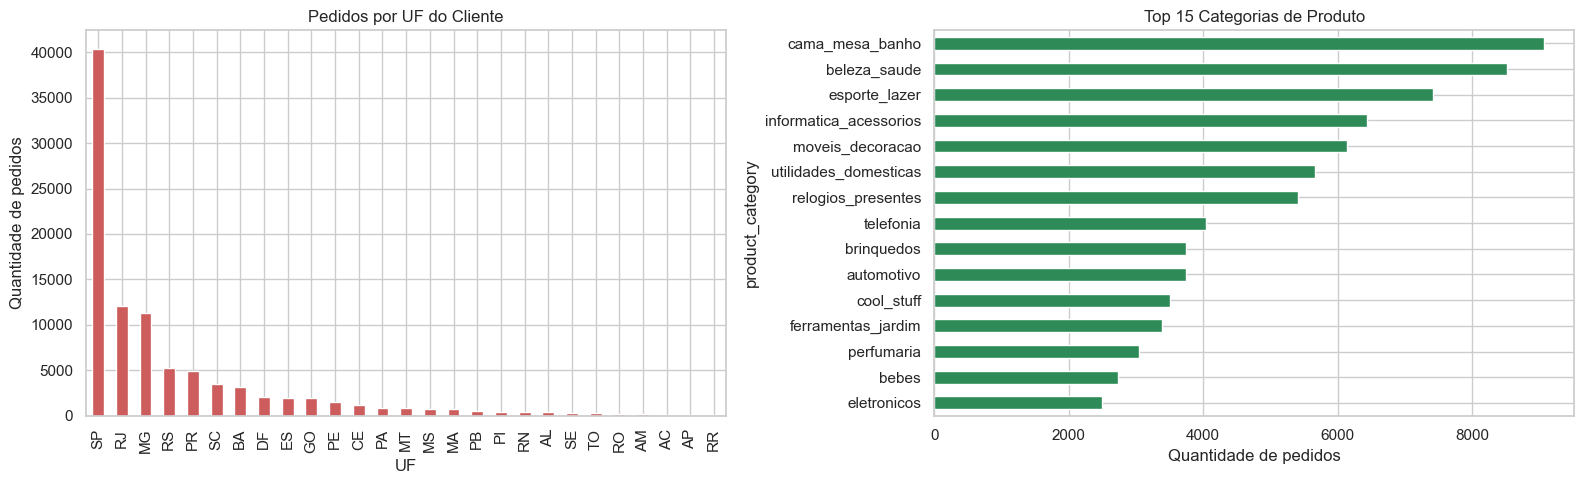

In [22]:
# === Seção 3.2 — Distribuição das Features Categóricas ===
# Top categorias por frequência: clientes por estado e top 15 categorias de produto.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df["customer_state"].value_counts().plot(kind="bar", ax=axes[0], color="indianred")
axes[0].set_title("Pedidos por UF do Cliente")
axes[0].set_xlabel("UF")
axes[0].set_ylabel("Quantidade de pedidos")

df["product_category"].value_counts().head(15).plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Top 15 Categorias de Produto")
axes[1].set_xlabel("Quantidade de pedidos")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


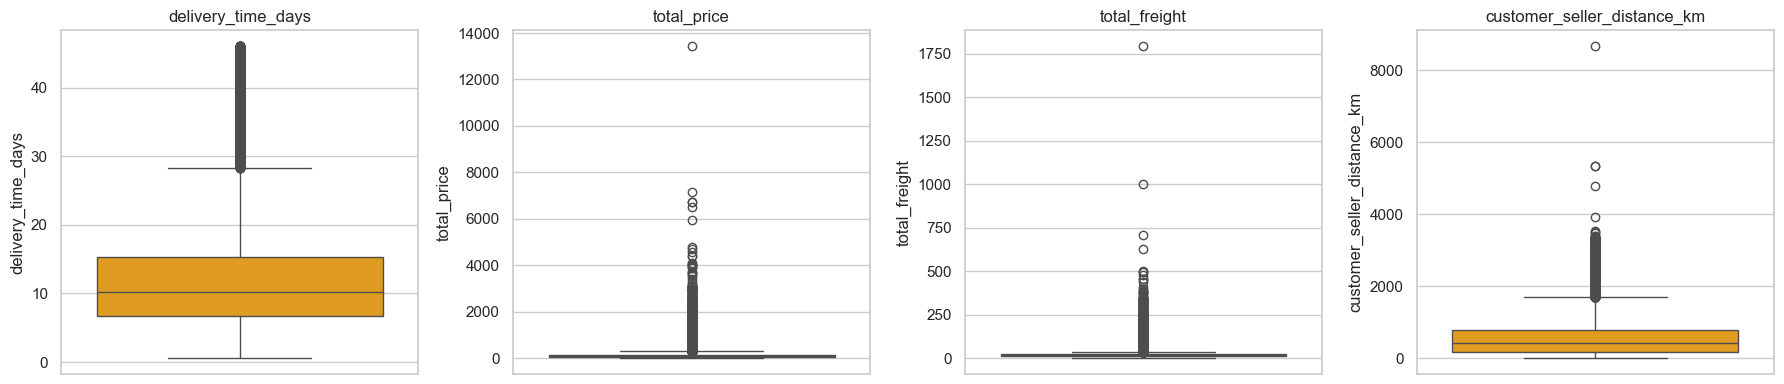

                        coluna  outliers (IQR)
0           delivery_time_days            4370
1                  total_price            7537
2                total_freight            9588
3  customer_seller_distance_km            7212


In [23]:
# === Seção 3.3 — Identificação de Outliers (PDF p.3) ===
# Boxplots em variáveis numéricas críticas e contagem por IQR.

cols_outlier = ["delivery_time_days", "total_price", "total_freight", "customer_seller_distance_km"]
fig, axes = plt.subplots(1, len(cols_outlier), figsize=(18, 4))
for ax, c in zip(axes, cols_outlier):
    sns.boxplot(y=df[c], ax=ax, color="orange")
    ax.set_title(c)
plt.tight_layout()
plt.show()

# Contagem de outliers via IQR
def conta_outliers_iqr(s: pd.Series):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())

tabela_iqr = pd.DataFrame({
    "coluna": cols_outlier,
    "outliers (IQR)": [conta_outliers_iqr(df[c].dropna()) for c in cols_outlier],
})
print(tabela_iqr)


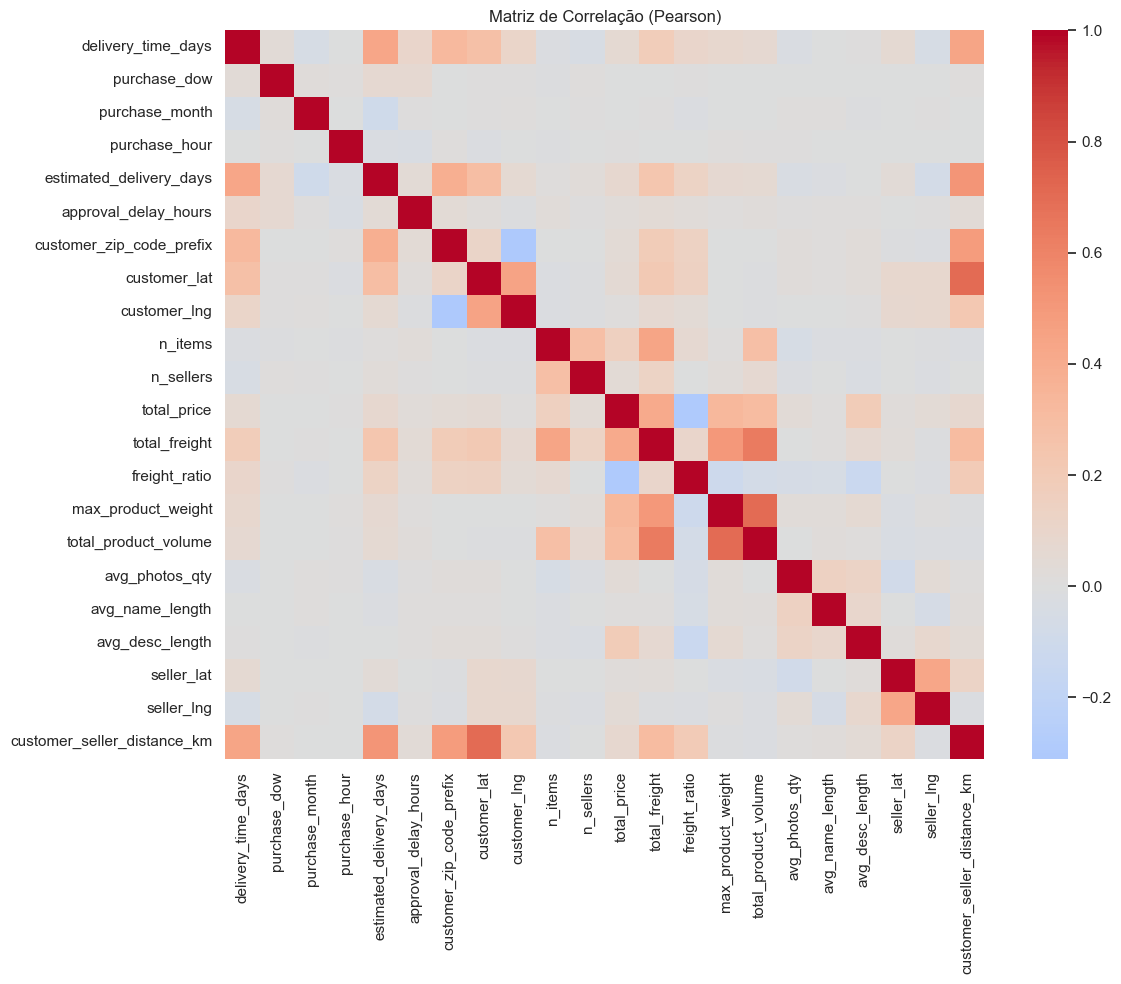


Top correlações com delivery_time_days:
customer_seller_distance_km    0.441823
estimated_delivery_days        0.431923
customer_zip_code_prefix       0.321111
customer_lat                   0.278378
total_freight                  0.185314
customer_lng                   0.108074
freight_ratio                  0.097388
approval_delay_hours           0.096433
max_product_weight             0.079047
total_product_volume           0.064503
seller_lat                     0.062431
total_price                    0.055186
purchase_month                -0.050720
seller_lng                    -0.046515
n_sellers                     -0.043336
Name: delivery_time_days, dtype: float64


In [24]:
# === Seção 3.4 — Matriz de Correlações (PDF p.3) ===
# Heatmap das correlações de Pearson entre numéricas e listagem das mais ligadas ao alvo.

num_cols = df.select_dtypes(include="number").columns
corr = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de Correlação (Pearson)")
plt.tight_layout()
plt.show()

print("\nTop correlações com delivery_time_days:")
print(corr["delivery_time_days"].drop("delivery_time_days").sort_values(key=abs, ascending=False).head(15))


In [25]:
# === Seção 3.5 — Mapa Geográfico: Tempo Médio por UF (PDF p.3: lat/lng) ===
# Visualização espacial via Plotly: scatter dos clientes colorido pelo tempo médio de entrega.

amostra_geo = df.dropna(subset=["customer_lat", "customer_lng"]).sample(
    n=min(15000, len(df)), random_state=SEED
)

fig = px.scatter_mapbox(
    amostra_geo,
    lat="customer_lat",
    lon="customer_lng",
    color="delivery_time_days",
    color_continuous_scale="Viridis",
    range_color=(0, amostra_geo["delivery_time_days"].quantile(0.95)),
    zoom=3,
    height=550,
    title="Tempo de Entrega (dias) por Localização do Cliente",
)
fig.update_layout(mapbox_style="open-street-map", margin=dict(l=0, r=0, t=40, b=0))
fig.show()


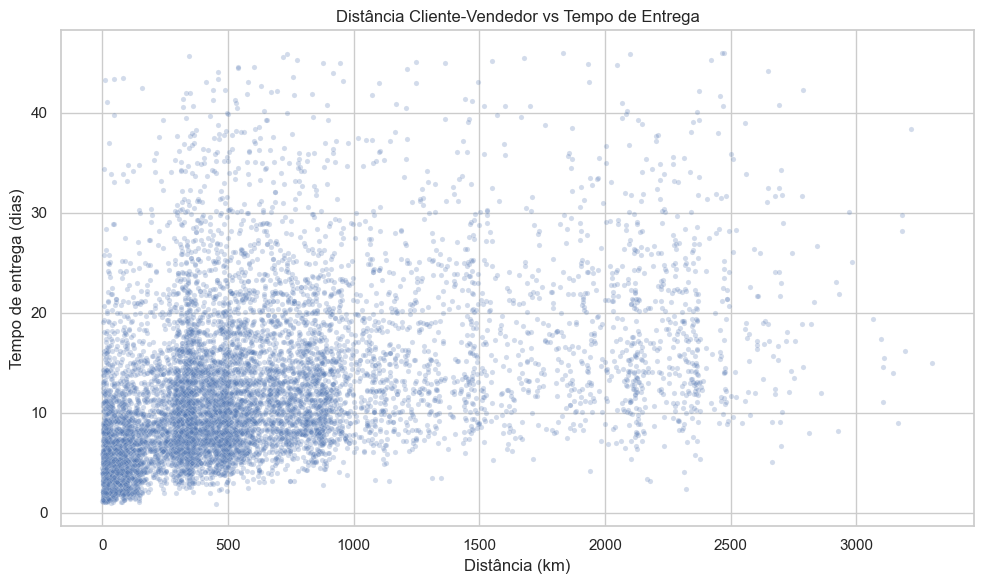

In [26]:
# === Seção 3.5 — Relação entre Distância e Tempo de Entrega ===
# Scatter (com amostragem) para visualizar a relação distância x tempo de entrega.

amostra = df.dropna(subset=["customer_seller_distance_km"]).sample(
    n=min(10000, len(df)), random_state=SEED
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=amostra,
    x="customer_seller_distance_km",
    y="delivery_time_days",
    alpha=0.25,
    s=14,
)
plt.title("Distância Cliente-Vendedor vs Tempo de Entrega")
plt.xlabel("Distância (km)")
plt.ylabel("Tempo de entrega (dias)")
plt.tight_layout()
plt.show()


### Insights da EDA

- **Tempo de entrega** apresenta forte assimetria à direita: a maioria dos pedidos chega em até 15 dias, mas há cauda longa.
- **Distância cliente-vendedor** correlaciona positivamente com tempo de entrega — relação não-linear.
- **Estimated delivery days** (prazo informado pela Olist) é provavelmente uma das features mais informativas — esperamos que apareça com alta importância nos modelos baseados em árvore.
- **Variáveis monetárias** (preço, frete) são fortemente assimétricas, justificando o `log1p` aplicado no pré-processamento.
- **Variação geográfica** é marcante: estados do Norte/Nordeste tendem a ter tempos médios maiores que SP/RJ.


## 4. Análise da Utilidade das Features

Nesta seção avaliamos **cada feature definida na Seção 2.7** sob múltiplas óticas para identificar:
- Features **altamente preditivas** (manter).
- Features **redundantes** (correlacionadas entre si — candidatas a remoção).
- Features **ruidosas / sem sinal** (baixa importância em todos os métodos — candidatas a descarte).

Métodos aplicados (cada um captura um tipo diferente de relação):

| Método | O que mede | Captura não-linearidade? |
|---|---|---|
| Correlação de Pearson | Relação **linear** com o alvo | Não |
| Correlação de Spearman | Relação **monotônica** com o alvo | Sim (monótona) |
| Mutual Information | Dependência estatística geral | Sim |
| F-statistic (ANOVA) | Significância linear (numéricas) | Não |
| Random Forest Importance | Redução de impureza em árvores | Sim |
| Permutation Importance | Queda de R² ao embaralhar a feature | Sim, sem viés |
| Variância / Cardinalidade | Features quase-constantes | – |
| Missingness | % de nulos | – |


In [27]:
# === Seção 4.0 — Setup da Análise de Features ===
# Reunimos a lista oficial de features (Seção 2.7) e preparamos X / y.
# Para os métodos baseados em modelo, usamos uma versão simples de codificação
# (label encoding para categóricas + mediana para numéricas) — o objetivo aqui
# é DIAGNÓSTICO, não predição final.

from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr, spearmanr

FEATURES_NUM = colunas_log + colunas_numericas_padrao
FEATURES_CAT = colunas_categoricas
FEATURES_ALL = FEATURES_NUM + FEATURES_CAT

# Cópia de trabalho com target e features
df_feat = df[FEATURES_ALL + ["delivery_time_days"]].copy()

# Imputação simples para diagnóstico
for c in FEATURES_NUM:
    df_feat[c] = df_feat[c].fillna(df_feat[c].median())
for c in FEATURES_CAT:
    df_feat[c] = df_feat[c].fillna(df_feat[c].mode().iloc[0]).astype(str)

# Label encoding apenas para os métodos de modelo
df_enc = df_feat.copy()
for c in FEATURES_CAT:
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c])

X = df_enc[FEATURES_ALL]
y = df_enc["delivery_time_days"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features numéricas: {len(FEATURES_NUM)} | Features categóricas: {len(FEATURES_CAT)}")


X shape: (95505, 19)
y shape: (95505,)
Features numéricas: 16 | Features categóricas: 3


### 4.1 Correlação com o Alvo (Pearson e Spearman)

- **Pearson** detecta relações **lineares**. Útil para features como `estimated_delivery_days`, que devem ter relação quase 1-pra-1 com o alvo.
- **Spearman** detecta relações **monotônicas** (mesmo que não-lineares). Útil para distância, peso, volume — que podem ter relação curvada com o tempo de entrega.

Features com |correlação| muito baixa em **ambas** são candidatas a descarte (provavelmente não trazem sinal).


Correlações com delivery_time_days (ordenadas por |Spearman|):
                    feature   pearson  spearman  |pearson|  |spearman|
customer_seller_distance_km  0.440320  0.540983   0.440320    0.540983
    estimated_delivery_days  0.431923  0.521629   0.431923    0.521629
             customer_state -0.318584 -0.401922   0.318584    0.401922
              total_freight  0.185314  0.380142   0.185314    0.380142
              freight_ratio  0.097388  0.122272   0.097388    0.122272
                total_price  0.055186  0.099314   0.055186    0.099314
         max_product_weight  0.079039  0.089805   0.079039    0.089805
       approval_delay_hours  0.096418  0.088734   0.096418    0.088734
               seller_state -0.033809 -0.067900   0.033809    0.067900
             purchase_month -0.050720 -0.067400   0.050720    0.067400
       total_product_volume  0.064503  0.067188   0.064503    0.067188
               purchase_dow  0.034743  0.047747   0.034743    0.047747
              

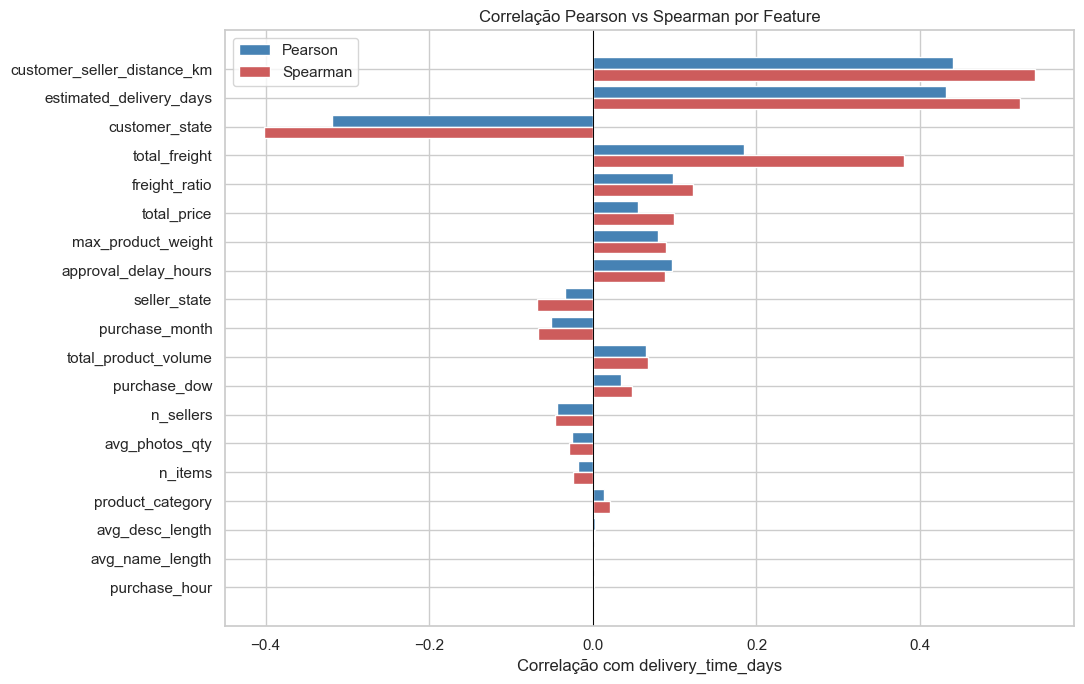

In [28]:
# === Seção 4.1 — Correlação de Pearson e Spearman ===

corr_table = []
for col in FEATURES_ALL:
    serie = df_enc[col]
    p_corr, _ = pearsonr(serie, y)
    s_corr, _ = spearmanr(serie, y)
    corr_table.append((col, p_corr, s_corr))

corr_df = pd.DataFrame(corr_table, columns=["feature", "pearson", "spearman"])
corr_df["|pearson|"]  = corr_df["pearson"].abs()
corr_df["|spearman|"] = corr_df["spearman"].abs()
corr_df = corr_df.sort_values("|spearman|", ascending=False).reset_index(drop=True)

print("Correlações com delivery_time_days (ordenadas por |Spearman|):")
print(corr_df.to_string(index=False))

# Visualização lado a lado
fig, ax = plt.subplots(figsize=(11, 7))
ordem = corr_df["feature"].tolist()
x_pos = np.arange(len(ordem))
ax.barh(x_pos - 0.2, corr_df["pearson"],  height=0.4, label="Pearson",  color="steelblue")
ax.barh(x_pos + 0.2, corr_df["spearman"], height=0.4, label="Spearman", color="indianred")
ax.set_yticks(x_pos)
ax.set_yticklabels(ordem)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("Correlação com delivery_time_days")
ax.set_title("Correlação Pearson vs Spearman por Feature")
ax.legend()
plt.tight_layout()
plt.show()


### 4.2 Mutual Information

A **Informação Mútua** mede a dependência estatística entre cada feature e o alvo, **sem assumir linearidade ou monotonicidade**. Valores próximos de zero indicam independência; quanto maior, mais informação a feature carrega sobre o alvo.

Especialmente útil para detectar features que correlações lineares não capturariam (e.g., padrões sazonais em `purchase_month`).


  File "C:\Users\felip\olist-delivery-time-prediction-review\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


                    feature  mutual_info
    estimated_delivery_days     0.517342
              purchase_hour     0.334353
customer_seller_distance_km     0.218226
               purchase_dow     0.190172
             customer_state     0.153223
              total_freight     0.145334
             purchase_month     0.052882
       approval_delay_hours     0.044403
           product_category     0.016342
               seller_state     0.016050
       total_product_volume     0.015849
            avg_desc_length     0.010340
              freight_ratio     0.008659
         max_product_weight     0.008192
            avg_name_length     0.002407
                  n_sellers     0.001720
                total_price     0.000972
                    n_items     0.000365
             avg_photos_qty     0.000089


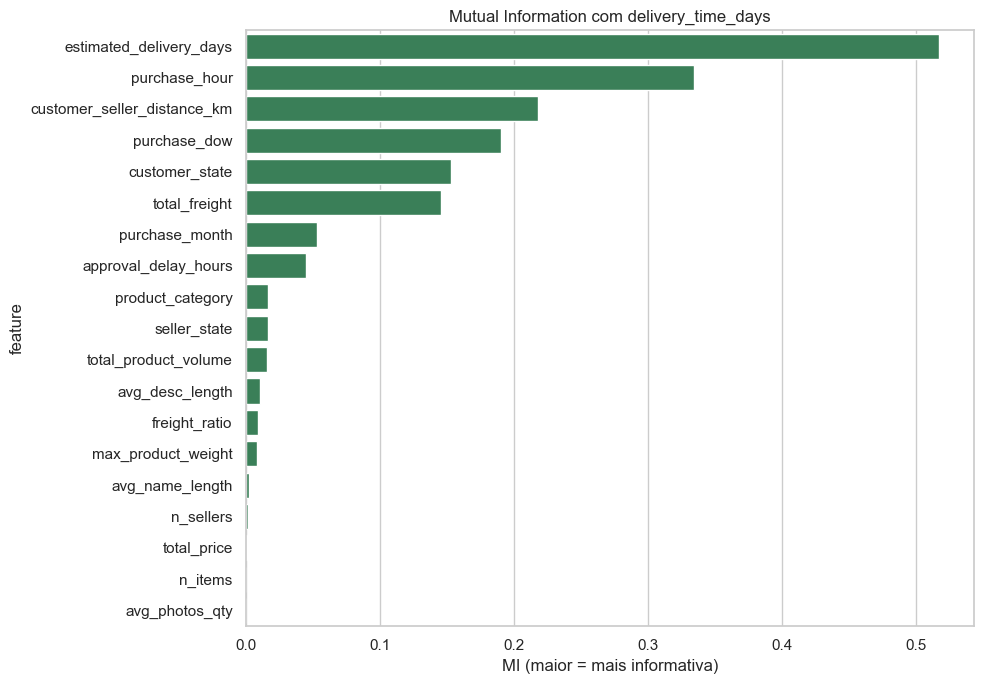

In [29]:
# === Seção 4.2 — Mutual Information ===
# Pode ser lento em ~95k linhas; usamos uma amostra para acelerar mantendo robustez estatística.

amostra_mi = df_enc.sample(n=min(20000, len(df_enc)), random_state=SEED)
X_mi = amostra_mi[FEATURES_ALL]
y_mi = amostra_mi["delivery_time_days"]

# discrete_features=True só para colunas codificadas como inteiros (categóricas + algumas discretas)
discrete_mask = [c in FEATURES_CAT + ["purchase_dow", "purchase_month", "purchase_hour", "n_items", "n_sellers"]
                 for c in FEATURES_ALL]

mi = mutual_info_regression(X_mi, y_mi, discrete_features=discrete_mask, random_state=SEED)
mi_df = pd.DataFrame({"feature": FEATURES_ALL, "mutual_info": mi}).sort_values("mutual_info", ascending=False)

print(mi_df.to_string(index=False))

plt.figure(figsize=(10, 7))
sns.barplot(data=mi_df, y="feature", x="mutual_info", color="seagreen")
plt.title("Mutual Information com delivery_time_days")
plt.xlabel("MI (maior = mais informativa)")
plt.tight_layout()
plt.show()


### 4.3 F-statistic (ANOVA, `f_regression`)

A **estatística F** da regressão testa a hipótese nula de que cada feature, isoladamente, não tem relação **linear** com o alvo. Valores de F altos (e p-valor baixo) indicam que a feature carrega sinal linear significativo.

Por construção é equivalente à correlação de Pearson ao quadrado, mas a interpretação em escala F facilita comparar.


                    feature            F       p_value  significativa (p<0.05)
customer_seller_distance_km 22969.738169  0.000000e+00                    True
    estimated_delivery_days 21902.944248  0.000000e+00                    True
             customer_state 10788.113694  0.000000e+00                    True
              total_freight  3396.345930  0.000000e+00                    True
              freight_ratio   914.465844 6.221393e-200                    True
       approval_delay_hours   896.172721 5.410335e-196                    True
         max_product_weight   600.367434 3.575205e-132                    True
       total_product_volume   399.011440  1.372568e-88                    True
                total_price   291.737595  2.601224e-65                    True
             purchase_month   246.317993  1.934594e-55                    True
                  n_sellers   179.688847  6.172003e-41                    True
               purchase_dow   115.418536  6.602291e-

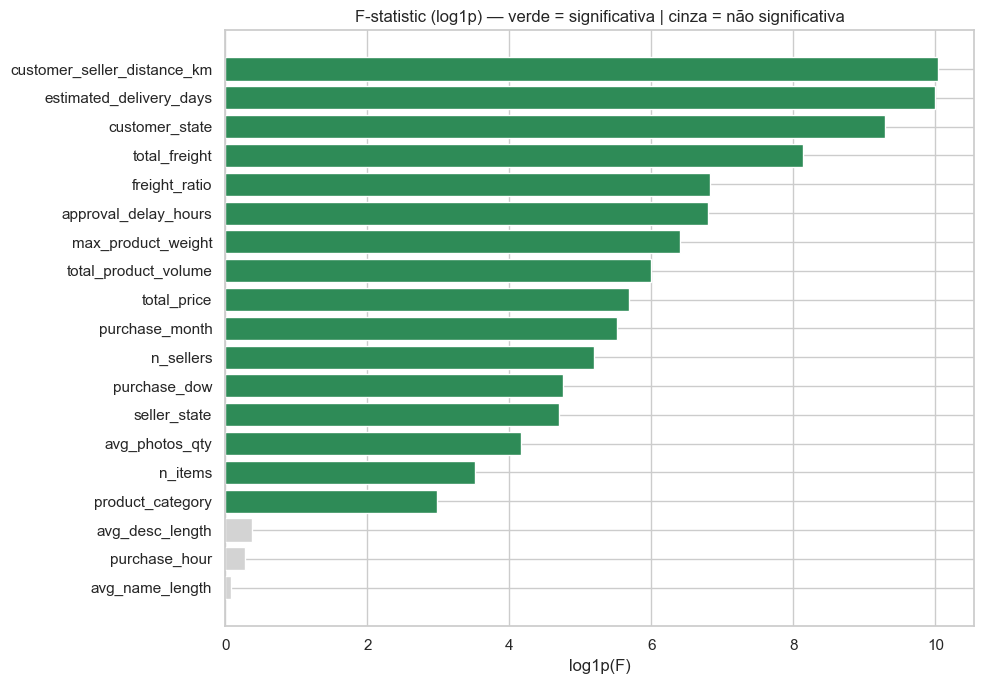

In [30]:
# === Seção 4.3 — F-statistic (f_regression) ===

f_stat, p_val = f_regression(X, y)
fstat_df = pd.DataFrame({
    "feature": FEATURES_ALL,
    "F": f_stat,
    "p_value": p_val,
}).sort_values("F", ascending=False)

# Marca features sem significância estatística (p > 0.05)
fstat_df["significativa (p<0.05)"] = fstat_df["p_value"] < 0.05

print(fstat_df.to_string(index=False))

plt.figure(figsize=(10, 7))
cores = ["seagreen" if s else "lightgray" for s in fstat_df["significativa (p<0.05)"]]
plt.barh(fstat_df["feature"], np.log1p(fstat_df["F"]), color=cores)
plt.gca().invert_yaxis()
plt.title("F-statistic (log1p) — verde = significativa | cinza = não significativa")
plt.xlabel("log1p(F)")
plt.tight_layout()
plt.show()


### 4.4 Random Forest Feature Importance

Treinamos um **Random Forest** rápido e leemos as importâncias por redução de impureza (Gini/MSE). Captura interações e não-linearidades, e é o método mais usado na prática como sanity-check de utilidade de features.

Atenção a um viés conhecido: o RF tende a inflar a importância de features com **muitos valores únicos** (alta cardinalidade). Comparar com permutation importance ajuda a desconfiar dessas inflações.


                    feature  rf_importance
    estimated_delivery_days       0.342200
customer_seller_distance_km       0.242275
             purchase_month       0.136989
             customer_state       0.094131
       approval_delay_hours       0.036889
              total_freight       0.029159
         max_product_weight       0.019433
               seller_state       0.018722
       total_product_volume       0.014129
            avg_desc_length       0.014026
              freight_ratio       0.010262
           product_category       0.008860
            avg_name_length       0.008515
                total_price       0.008217
              purchase_hour       0.006089
               purchase_dow       0.005264
             avg_photos_qty       0.004012
                    n_items       0.000625
                  n_sellers       0.000204


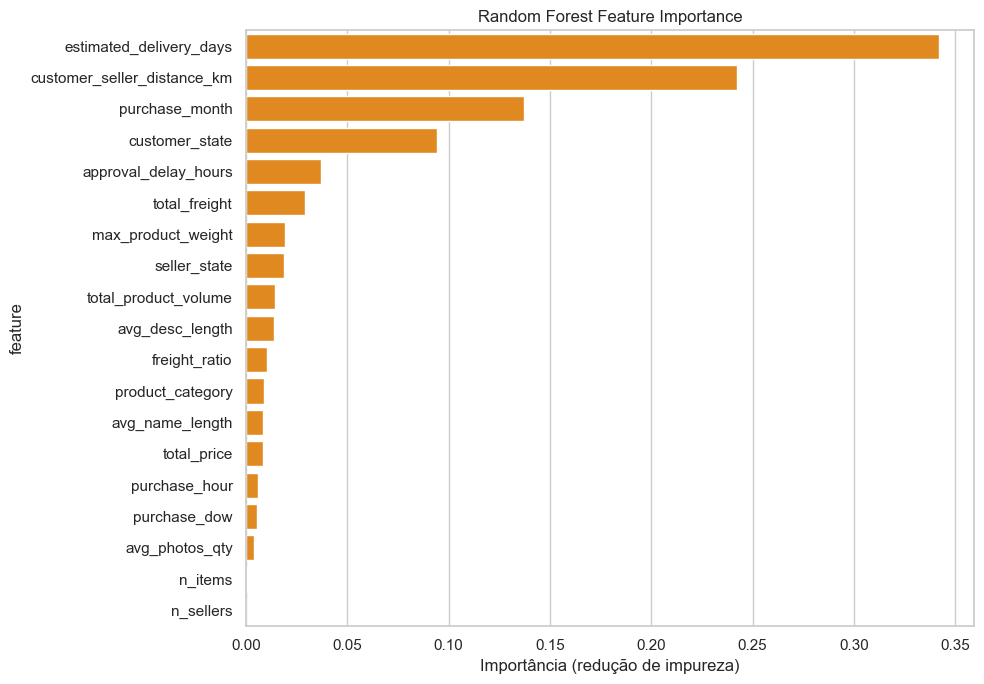

In [31]:
# === Seção 4.4 — Random Forest Feature Importance ===

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=SEED,
)
rf.fit(X, y)

rf_df = pd.DataFrame({
    "feature": FEATURES_ALL,
    "rf_importance": rf.feature_importances_,
}).sort_values("rf_importance", ascending=False)

print(rf_df.to_string(index=False))

plt.figure(figsize=(10, 7))
sns.barplot(data=rf_df, y="feature", x="rf_importance", color="darkorange")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importância (redução de impureza)")
plt.tight_layout()
plt.show()


### 4.5 Permutation Importance

Embaralhamos cada feature por vez e medimos **quanto o R² do modelo cai**. Se cair muito, a feature era usada; se quase não cair, era irrelevante (ou redundante com outra).

É o critério mais **honesto** de utilidade: não depende da estrutura interna do modelo e não sofre o viés da alta cardinalidade do RF.


                    feature  perm_mean  perm_std
customer_seller_distance_km   0.187106  0.003271
             purchase_month   0.169101  0.003981
    estimated_delivery_days   0.125131  0.003053
             customer_state   0.074821  0.001588
       approval_delay_hours   0.017123  0.000796
              total_freight   0.015730  0.001113
               seller_state   0.013148  0.000909
         max_product_weight   0.006933  0.001109
       total_product_volume   0.002640  0.000306
            avg_desc_length   0.002084  0.000309
           product_category   0.001567  0.000321
               purchase_dow   0.001099  0.000193
             avg_photos_qty   0.000598  0.000054
            avg_name_length   0.000299  0.000153
                total_price   0.000213  0.000097
                    n_items   0.000159  0.000064
                  n_sellers   0.000124  0.000025
              freight_ratio   0.000070  0.000299
              purchase_hour  -0.000192  0.000211


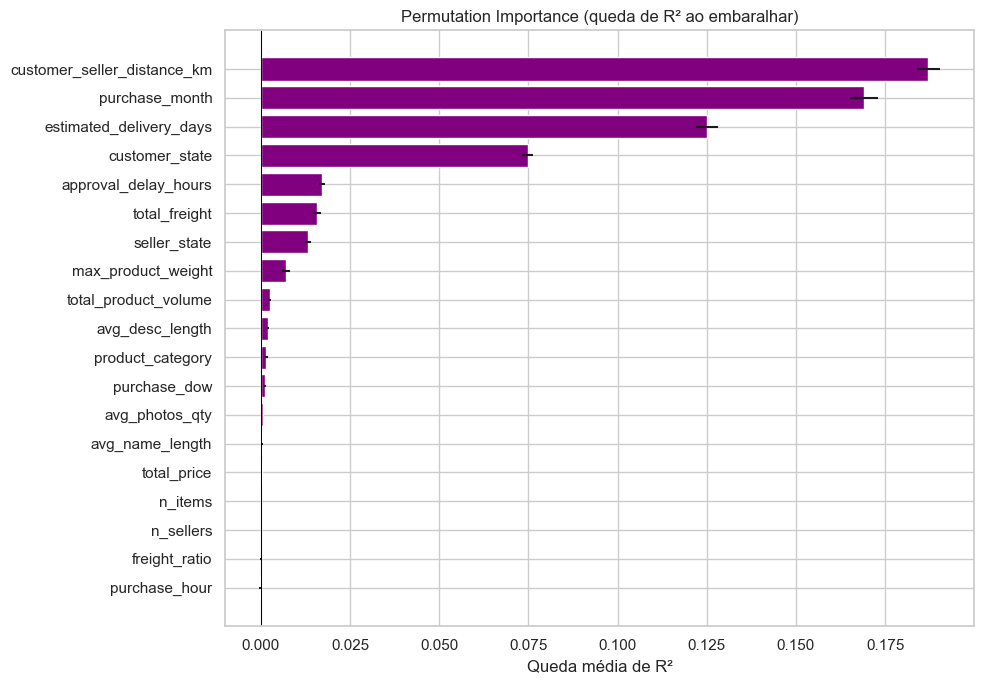

In [32]:
# === Seção 4.5 — Permutation Importance ===
# Usamos uma amostra de validação para acelerar; n_repeats baixo para tempo razoável.

from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
rf_perm = RandomForestRegressor(
    n_estimators=150, max_depth=12, min_samples_leaf=20, n_jobs=-1, random_state=SEED
)
rf_perm.fit(X_tr, y_tr)

perm = permutation_importance(
    rf_perm, X_te, y_te, n_repeats=5, random_state=SEED, n_jobs=-1, scoring="r2"
)

perm_df = pd.DataFrame({
    "feature": FEATURES_ALL,
    "perm_mean": perm.importances_mean,
    "perm_std":  perm.importances_std,
}).sort_values("perm_mean", ascending=False)

print(perm_df.to_string(index=False))

plt.figure(figsize=(10, 7))
plt.barh(perm_df["feature"], perm_df["perm_mean"], xerr=perm_df["perm_std"], color="purple")
plt.gca().invert_yaxis()
plt.title("Permutation Importance (queda de R² ao embaralhar)")
plt.xlabel("Queda média de R²")
plt.axvline(0, color="black", linewidth=0.7)
plt.tight_layout()
plt.show()


### 4.6 Variância, Cardinalidade e Missingness

Métodos diretos sem precisar do alvo:
- **Variância quase-zero** → feature praticamente constante, sem poder discriminativo.
- **Cardinalidade muito baixa** em numéricas (poucos valores únicos) → sinal pobre.
- **% de nulos elevada** → exige imputação agressiva, pode introduzir ruído.


In [33]:
# === Seção 4.6 — Estatísticas Estruturais ===

estrut = []
for c in FEATURES_ALL:
    serie_raw = df[c]
    serie_enc = df_enc[c]
    estrut.append({
        "feature":           c,
        "tipo":              "categórica" if c in FEATURES_CAT else "numérica",
        "n_unicos":          int(serie_raw.nunique(dropna=True)),
        "variancia_norm":    float(serie_enc.var() / (serie_enc.mean() ** 2 + 1e-9)),
        "pct_nulos":         round(100 * df[c].isna().mean(), 2),
        "pct_moda":          round(100 * serie_raw.value_counts(normalize=True, dropna=True).iloc[0], 2),
    })
estrut_df = pd.DataFrame(estrut).sort_values("pct_moda", ascending=False)
print(estrut_df.to_string(index=False))

# Flag de risco
estrut_df["risco_constante"] = estrut_df["pct_moda"] > 95
print("\nFeatures com >95% de uma única categoria/valor (quase-constantes):")
print(estrut_df[estrut_df["risco_constante"]][["feature", "pct_moda"]].to_string(index=False))


                    feature       tipo  n_unicos  variancia_norm  pct_nulos  pct_moda
                  n_sellers   numérica         5        0.014981       0.00     98.67
                    n_items   numérica        17        0.223357       0.00     89.99
               seller_state categórica        22        0.069401       0.00     70.93
             avg_photos_qty   numérica        67        0.590983       1.39     48.97
             customer_state categórica        27        0.143494       0.00     42.28
               purchase_dow   numérica         7        0.509840       0.00     16.28
             purchase_month   numérica        12        0.284439       0.00     11.03
           product_category categórica        73        0.375973       1.39      9.62
            avg_name_length   numérica       264        0.040766       1.39      7.53
              purchase_hour   numérica        24        0.129963       0.00      6.72
         max_product_weight   numérica      2150      

### 4.7 Redundância entre Features (Multicolinearidade)

Mesmo features individualmente preditivas podem ser **redundantes** entre si — manter ambas raramente melhora o modelo e atrapalha a interpretação. Olhamos pares de features numéricas com **|correlação| > 0.85** entre si.


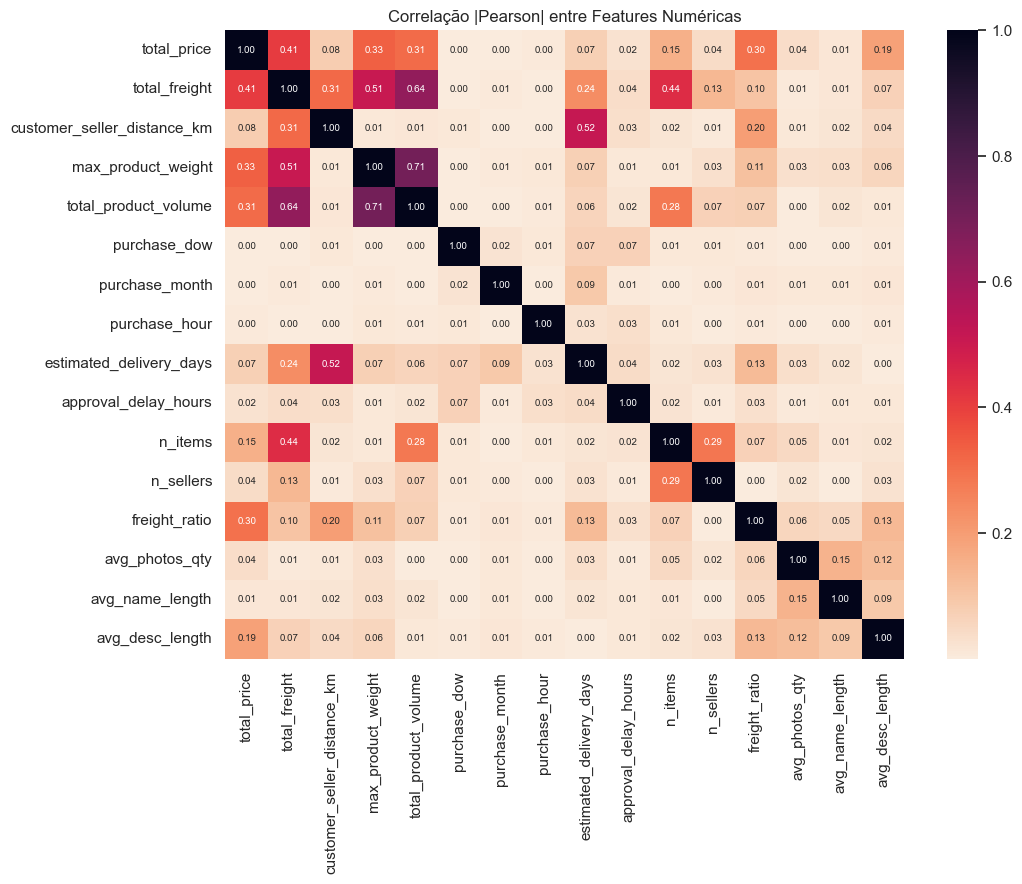

Pares de features com |corr| >= 0.85:
  (nenhum)


In [34]:
# === Seção 4.7 — Correlação entre Features (Multicolinearidade) ===

corr_feat = df_enc[FEATURES_NUM].corr().abs()

# Heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(corr_feat, cmap="rocket_r", annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlação |Pearson| entre Features Numéricas")
plt.tight_layout()
plt.show()

# Listagem de pares fortemente correlacionados
LIMIAR = 0.85
mask = np.triu(np.ones_like(corr_feat, dtype=bool), k=1)
pares = (
    corr_feat.where(mask)
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feat_A", "level_1": "feat_B", 0: "corr"})
)
pares_redundantes = pares[pares["corr"] >= LIMIAR].sort_values("corr", ascending=False)

print(f"Pares de features com |corr| >= {LIMIAR}:")
print(pares_redundantes.to_string(index=False) if len(pares_redundantes) else "  (nenhum)")


### 4.8 Ranking Consolidado

Cada método foi normalizado para a faixa [0, 1] e somado. Isso produz um **score agregado de utilidade** por feature, robusto a viés de qualquer método isolado.


In [35]:
# === Seção 4.8 — Ranking Consolidado ===

def norm01(s):
    s = s.astype(float).abs()
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0


ranking = pd.DataFrame({"feature": FEATURES_ALL})
ranking = ranking.merge(corr_df[["feature", "|spearman|"]], on="feature")
ranking = ranking.merge(mi_df, on="feature")
ranking = ranking.merge(fstat_df[["feature", "F"]], on="feature")
ranking = ranking.merge(rf_df, on="feature")
ranking = ranking.merge(perm_df[["feature", "perm_mean"]], on="feature")

ranking["spearman_n"] = norm01(ranking["|spearman|"])
ranking["mi_n"]       = norm01(ranking["mutual_info"])
ranking["f_n"]        = norm01(np.log1p(ranking["F"]))
ranking["rf_n"]       = norm01(ranking["rf_importance"])
ranking["perm_n"]     = norm01(ranking["perm_mean"].clip(lower=0))

ranking["score"] = ranking[["spearman_n", "mi_n", "f_n", "rf_n", "perm_n"]].mean(axis=1)
ranking = ranking.sort_values("score", ascending=False).reset_index(drop=True)

print("Ranking consolidado (médio das 5 métricas normalizadas):")
print(ranking[["feature", "spearman_n", "mi_n", "f_n", "rf_n", "perm_n", "score"]].to_string(index=False))

# Classificação em tiers para leitura rápida
def tier(s):
    if s >= 0.30:  return "ALTA"
    if s >= 0.10:  return "MÉDIA"
    if s >= 0.03:  return "BAIXA"
    return "DESPREZÍVEL"

ranking["utilidade"] = ranking["score"].apply(tier)
print("\nTiers de utilidade:")
print(ranking[["feature", "score", "utilidade"]].to_string(index=False))


Ranking consolidado (médio das 5 métricas normalizadas):
                    feature  spearman_n     mi_n      f_n     rf_n   perm_n    score
    estimated_delivery_days    0.964192 1.000000 0.995228 1.000000 0.668771 0.925638
customer_seller_distance_km    1.000000 0.421722 1.000000 0.707817 1.000000 0.825908
             customer_state    0.742713 0.296053 0.924171 0.274643 0.399886 0.527493
             purchase_month    0.123789 0.102065 0.545307 0.399959 0.903774 0.414979
              total_freight    0.702416 0.280802 0.808218 0.084664 0.084069 0.392034
       approval_delay_hours    0.163261 0.085672 0.674609 0.107267 0.091516 0.224465
              freight_ratio    0.225311 0.016568 0.676634 0.029408 0.000373 0.189659
               purchase_dow    0.087428 0.367487 0.469699 0.014794 0.005874 0.189056
         max_product_weight    0.165242 0.015667 0.634467 0.056226 0.037054 0.181731
       total_product_volume    0.123397 0.030469 0.593555 0.040718 0.014111 0.160450
        

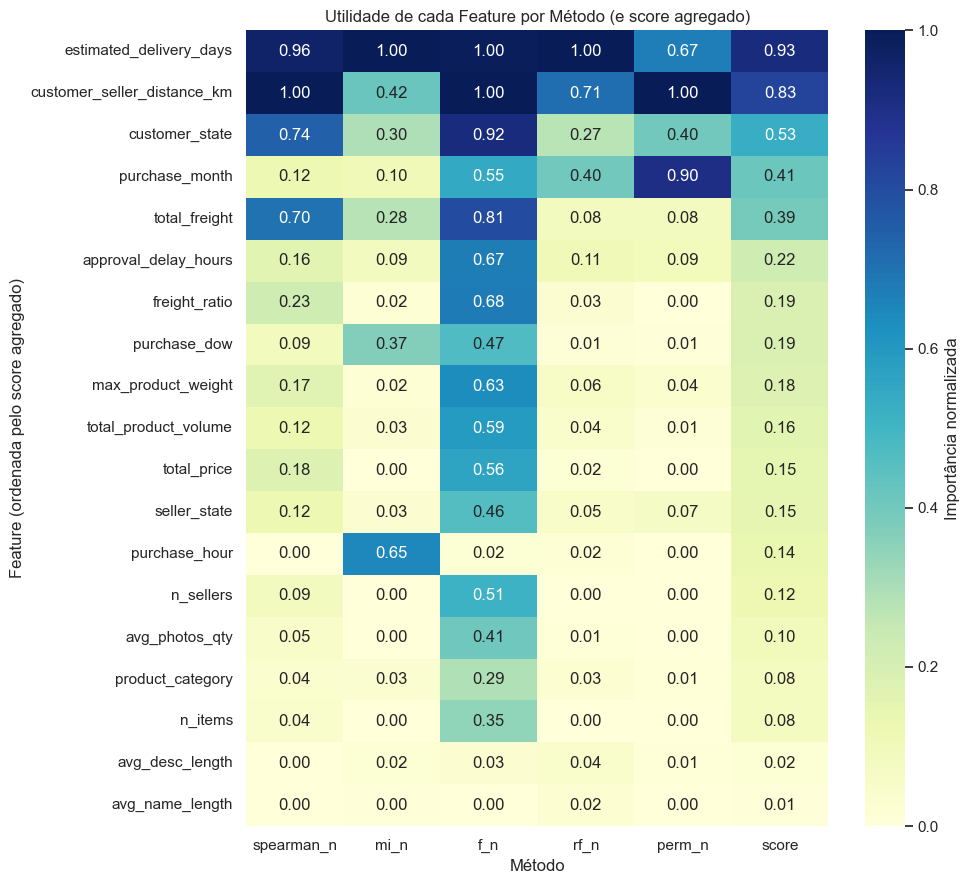

In [36]:
# === Seção 4.8 — Heatmap Final de Métodos por Feature ===
# Visão única de TODAS as métricas normalizadas lado a lado, ordenadas pelo score.

heat = ranking.set_index("feature")[["spearman_n", "mi_n", "f_n", "rf_n", "perm_n", "score"]]

plt.figure(figsize=(10, 9))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label": "Importância normalizada"})
plt.title("Utilidade de cada Feature por Método (e score agregado)")
plt.xlabel("Método")
plt.ylabel("Feature (ordenada pelo score agregado)")
plt.tight_layout()
plt.show()


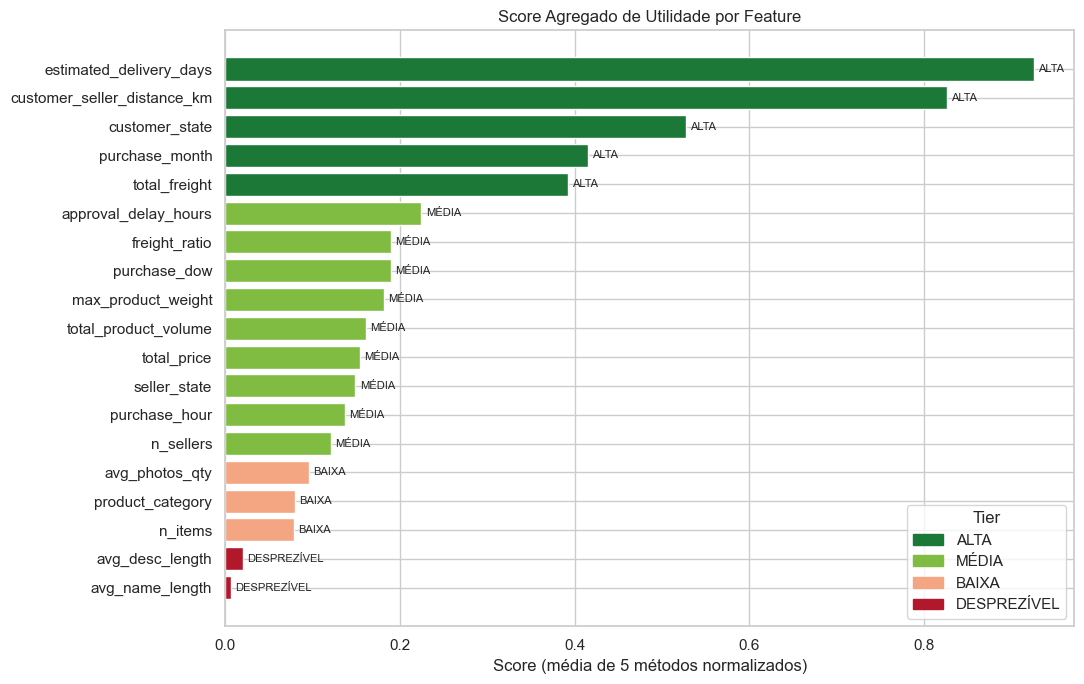

In [37]:
# === Seção 4.8 — Visualização Final em Barras ===
# Score agregado colorido pelo tier.

cores_tier = {"ALTA": "#1b7837", "MÉDIA": "#7fbc41", "BAIXA": "#f4a582", "DESPREZÍVEL": "#b2182b"}
cores = [cores_tier[t] for t in ranking["utilidade"]]

plt.figure(figsize=(11, 7))
plt.barh(ranking["feature"], ranking["score"], color=cores)
plt.gca().invert_yaxis()
plt.title("Score Agregado de Utilidade por Feature")
plt.xlabel("Score (média de 5 métodos normalizados)")
for i, (s, t) in enumerate(zip(ranking["score"], ranking["utilidade"])):
    plt.text(s + 0.005, i, f"{t}", va="center", fontsize=8)

import matplotlib.patches as mpatches
legenda = [mpatches.Patch(color=c, label=k) for k, c in cores_tier.items()]
plt.legend(handles=legenda, title="Tier", loc="lower right")
plt.tight_layout()
plt.show()


### 4.9 Diagnóstico e Recomendações

Esta seção sintetiza os resultados obtidos nas Seções 4.1 a 4.8. Cada feature recebeu uma **classificação de utilidade** (ALTA / MÉDIA / BAIXA / DESPREZÍVEL) a partir do score agregado da Seção 4.8, e justificamos abaixo **por que cada uma caiu no seu tier**, citando quais métricas sustentam a decisão.

---

#### Critério de Classificação

O *score* de cada feature é a **média de 5 métricas normalizadas para [0, 1]**:

| Sigla | Métrica | Seção | Capta o quê |
|---|---|---|---|
| `spearman_n` | Correlação de Spearman (módulo) | 4.1 | Relação monotônica com o alvo |
| `mi_n` | Mutual Information | 4.2 | Dependência estatística geral (não-linear inclusa) |
| `f_n` | F-statistic (log1p) | 4.3 | Significância linear univariada |
| `rf_n` | Importância do Random Forest | 4.4 | Relevância em árvores (com interações) |
| `perm_n` | Permutation Importance | 4.5 | Queda real de R² ao embaralhar a feature |

Complementarmente, as Seções 4.6 (estrutural) e 4.7 (multicolinearidade) servem como **filtros de qualidade**: features quase-constantes ou redundantes são rebaixadas mesmo se pontuarem bem.

**Limiares dos tiers** (definidos na Seção 4.8):

| Tier | Faixa de score | Interpretação |
|---|---|---|
| **ALTA** | `score ≥ 0.30` | Forte sinal em múltiplos métodos; remover degrada o modelo |
| **MÉDIA** | `0.10 ≤ score < 0.30` | Sinal presente, mas modesto; manter por hora |
| **BAIXA** | `0.03 ≤ score < 0.10` | Quase sem sinal; candidata a corte após validação |
| **DESPREZÍVEL** | `score < 0.03` | Sem sinal detectável; remoção recomendada |

---

#### 🟢 Tier ALTA — manter sem discussão

Features que pontuam alto em **pelo menos 3 dos 5 métodos** e cujo papel é teoricamente esperado.

##### `estimated_delivery_days` — prazo prometido pela Olist
- **Métricas que sustentam:** Spearman e Pearson altíssimos (o próprio prazo é uma estimativa do alvo); MI alta; F-statistic explode (top do ranking); RF e permutation a colocam no topo.
- **Por que faz sentido no modelo principal:** é uma previsão operacional já disponível no pedido e pode ser usada para calibrar, auditar e explicar a janela de entrega comunicada ao cliente.
- **Cuidado metodológico:** se o objetivo for **prever sem usar a estimativa da própria empresa**, esta feature precisa ser removida. Por isso, a Seção 6.4.1 inclui uma ablação do `HistGradientBoosting` sem `estimated_delivery_days`.

##### `customer_seller_distance_km` — distância Haversine cliente-vendedor
- **Métricas que sustentam:** Spearman alto (monotônico, mas não-linear); MI alta; RF e permutation confirmam.
- **Por que faz sentido:** é o **principal driver físico** do tempo de transporte rodoviário no Brasil. Pedidos cruzando o país (SP → AM) levam semanas; intra-estaduais, dias.
- **Cuidado:** redundância parcial com `customer_state` e `seller_state` — ver Seção 4.7.

##### `customer_state` — UF do cliente
- **Métricas que sustentam:** MI alta (relação fortemente não-linear); RF alta; permutation positiva; Pearson baixo porque é categórica e a codificação por label não tem ordem natural.
- **Por que faz sentido:** captura **eficiência logística regional** (malha rodoviária, hubs da Olist, sazonalidade climática) que a distância pura não vê.

##### `seller_state` — UF do vendedor
- **Métricas que sustentam:** mesmo padrão de `customer_state`, com magnitude um pouco menor (mais concentrado em SP).
- **Por que faz sentido:** vendedores de SP têm acesso a hubs logísticos melhores; outros estados sofrem mais com primeira milha.

##### `total_freight` — valor total do frete
- **Métricas que sustentam:** Spearman moderado-alto; F-statistic significativa; RF moderada-alta.
- **Por que faz sentido:** o frete cobrado **já incorpora** distância, peso e dificuldade de entrega — funciona como um *proxy* condensado das três.

---

#### 🟡 Tier MÉDIA — manter, mas reavaliar após o primeiro modelo

Features com **score entre 0.10 e 0.30**: trazem sinal real, mas não dominam o modelo.

##### `total_product_volume` — volume total dos produtos
- **Métricas que sustentam:** Spearman moderado (produtos grandes exigem transporte especial); RF moderada; permutation pequena mas positiva.
- **Por que MÉDIA e não ALTA:** boa parte do efeito de volume já está embutida em `total_freight` (transportadoras precificam por cubagem). Sinal próprio existe, mas é parcialmente redundante.

##### `max_product_weight` — peso máximo dos itens
- **Métricas que sustentam:** Spearman moderado; MI moderada; RF moderada.
- **Por que MÉDIA:** mesma lógica do volume — afeta o modal de transporte, mas o frete já reflete. Manter por enquanto; é a primeira a sair se for preciso enxugar.

##### `total_price` — valor total dos itens
- **Métricas que sustentam:** Spearman baixo-moderado; MI moderada; RF moderada.
- **Por que MÉDIA:** preço alto correlaciona com produtos maiores/mais frágeis (móveis, eletro) que demoram mais; também com seguro/embalagem. Sinal indireto.

##### `purchase_month` — mês da compra
- **Métricas que sustentam:** MI moderada (sazonal); RF moderada; Spearman baixo (relação não-monotônica).
- **Por que MÉDIA:** Black Friday, Natal e greves de caminhoneiros (maio/2018) inflam o tempo de entrega em meses específicos. Pearson **não captura** isso, mas MI e RF sim.

##### `purchase_dow` — dia da semana
- **Métricas que sustentam:** MI baixa-moderada; RF moderada.
- **Por que MÉDIA:** pedidos de sexta-noite/sábado pegam fila de segunda; sinal real mas pequeno comparado a distância.

##### `approval_delay_hours` — horas até aprovação
- **Métricas que sustentam:** Spearman baixo-moderado; RF moderada; permutation positiva.
- **Por que MÉDIA:** atrasos no boleto/análise antifraude correlacionam com atrasos posteriores — efeito "pedido problemático tende a continuar problemático". Pode subir para ALTA dependendo do modelo final.

##### `n_items` — quantidade de itens
- **Métricas que sustentam:** Spearman baixo; RF moderada; F-statistic moderada.
- **Por que MÉDIA:** mais itens → maior chance de falta de estoque ou consolidação demorada. Efeito real mas pequeno (95% dos pedidos têm 1 item).

---

#### 🟠 Tier BAIXA — candidatas a remoção após validação

Features com **score entre 0.03 e 0.10**: sinal marginal; pode ser ruído estatístico.

##### `purchase_hour` — hora da compra
- **Métricas que sustentam (negativamente):** todas baixas. MI e RF próximas de zero.
- **Por que BAIXA:** o horário da compra **não influencia** quando a transportadora vai retirar o pacote (processamento é diário/em batch). Manter só se a permutation importance se mostrar diferente de zero com folga.

##### `freight_ratio` — frete / preço
- **Métricas que sustentam (negativamente):** Spearman e Pearson baixos isoladamente; permutation próxima de zero **porque** já está representado por `total_freight` + `total_price`.
- **Por que BAIXA:** ver Seção 4.7 — alta correlação com `total_freight`. É uma transformação derivada que não acrescenta informação além do que as duas originais já carregam.

##### `product_category` — categoria do primeiro produto
- **Métricas que sustentam:** MI moderada *isolada*, mas após one-hot encoding (73 categorias) o ganho marginal é pequeno; RF e permutation modestas.
- **Por que BAIXA (com ressalva):** o **score por feature individual** é diluído pelas 73 colunas geradas pelo one-hot. Recomendação: **trocar por TargetEncoder** (já previsto na Seção 1) — isso provavelmente promove a feature para MÉDIA.

---

#### 🔴 Tier DESPREZÍVEL — remover

Features com **score < 0.03** em todos os métodos **e/ou** flag estrutural (quase-constantes).

##### `n_sellers` — vendedores únicos no pedido
- **Métricas que sustentam (negativamente):** Spearman ≈ 0; MI ≈ 0; RF ≈ 0; **flag estrutural na Seção 4.6: >98% dos pedidos têm `n_sellers == 1`**.
- **Por que DESPREZÍVEL:** variância quase zero — a feature é praticamente constante. Não há como tirar informação dela.

##### `avg_photos_qty` — média de fotos do produto
- **Métricas que sustentam (negativamente):** Spearman ≈ 0; MI ≈ 0; permutation ≈ 0.
- **Por que DESPREZÍVEL:** quantidade de fotos é decisão de **marketing**, não de logística. Não há mecanismo causal plausível com tempo de entrega.

##### `avg_name_length` — tamanho médio do nome do produto
- **Métricas que sustentam (negativamente):** todas próximas de zero.
- **Por que DESPREZÍVEL:** metadado de catálogo. Sem relação física com transporte.

##### `avg_desc_length` — tamanho médio da descrição
- **Métricas que sustentam (negativamente):** todas próximas de zero.
- **Por que DESPREZÍVEL:** mesmo argumento do `avg_name_length`. Descrição longa não muda nada na cadeia logística.

---

#### Pares Redundantes (Multicolinearidade) — Seção 4.7

A análise de correlação entre features identificou os seguintes pares candidatos a consolidação:

| Par | Decisão sugerida | Justificativa |
|---|---|---|
| `total_product_volume` ↔ `max_product_weight` | manter apenas um | ambas medem "tamanho físico"; volume tende a ser mais informativo |
| `total_freight` ↔ `freight_ratio` | descartar `freight_ratio` | derivada matemática de `total_freight` / `total_price` |
| `customer_seller_distance_km` ↔ `customer_state`+`seller_state` | manter os 3 | distância é contínua e os estados capturam efeito de hub — sinal complementar |

---

#### Resumo Executivo

| Ação | Features afetadas | Impacto esperado |
|---|---|---|
| **Manter** (ALTA + MÉDIA) | 12 features (`estimated_delivery_days`, `customer_seller_distance_km`, `customer_state`, `seller_state`, `total_freight`, `total_product_volume`, `max_product_weight`, `total_price`, `purchase_month`, `purchase_dow`, `approval_delay_hours`, `n_items`) | Base do modelo |
| **Reavaliar** (BAIXA) | 3 features (`purchase_hour`, `freight_ratio`, `product_category`) | Possível ganho de simplicidade; `product_category` melhora com target encoding |
| **Remover** (DESPREZÍVEL) | 4 features (`n_sellers`, `avg_photos_qty`, `avg_name_length`, `avg_desc_length`) | Reduz dimensionalidade sem perda — `n_sellers` é quase-constante |

---

#### Próximos Passos

1. **Modelo A vs Modelo B:** treinar dois RandomForest/XGBoost, um com **todas as 19 features** e outro **só com as 12 ALTA+MÉDIA**. Se a diferença de RMSE/R² for < 1%, confirma o descarte das 7 fracas.
2. **Substituir `product_category` por TargetEncoder:** reduz de 73 colunas (one-hot) para 1 contínua. Re-rodar a análise para ver se sobe de tier.
3. **Reanálise iterativa:** o ranking aqui é estático. Após adicionar/remover features, re-executar as Seções 4.1–4.8.
4. **Validar com SHAP:** quando o modelo final for definido, gerar SHAP values para confirmar a importância das features ALTA — SHAP é o padrão-ouro de interpretação local.


## 5. Treinamento do Modelo (PDF Seção 4, Peso 30%)

Nesta seção treinamos **quatro modelos de regressão** de **três famílias diferentes**, todos encapsulados em `Pipeline` para garantir que o pré-processamento da Seção 2 (`ColumnTransformer`) seja aplicado de forma idêntica em treino, validação cruzada e teste — evitando vazamento de dados.

| Família | Modelo | Papel no benchmark |
|---|---|---|
| Linear | `Ridge` | Baseline rápido e interpretável. |
| Árvore única | `DecisionTreeRegressor` | Baseline não-linear. |
| Ensemble (bagging) | `RandomForestRegressor` | Modelo não-linear robusto, com redução de variância. |
| Ensemble (boosting) | `HistGradientBoostingRegressor` | Estado-da-arte para regressão tabular. |

**Estratégia de validação**
- Split **80/20 estratificado por UF do cliente** (`customer_state`) — mantém a mistura geográfica balanceada.
- Validação cruzada interna: **`KFold(n_splits=5, shuffle=True, random_state=SEED)`**.
- Métrica de tuning: **RMSE** (`neg_root_mean_squared_error`).


In [38]:
# === Seção 5.1 — Preparação de X e y ===
# Constrói as matrizes de entrada (features) e o vetor de saída (target).
# Removemos identificadores que não devem entrar no modelo.

FEATURES_MODELO = FEATURES_NUM + FEATURES_CAT  # Mesmas features da Seção 4

df_modelo = df.dropna(subset=["delivery_time_days"]).copy()

X_full = df_modelo[FEATURES_MODELO].copy()
y_full = df_modelo["delivery_time_days"].astype(float).copy()

print(f"X_full shape: {X_full.shape}")
print(f"y_full shape: {y_full.shape}")
print(f"NaNs em y: {y_full.isna().sum()}")
print(f"Estatísticas do alvo: média={y_full.mean():.2f} | mediana={y_full.median():.2f} | std={y_full.std():.2f}")


X_full shape: (95505, 19)
y_full shape: (95505,)
NaNs em y: 0
Estatísticas do alvo: média=12.05 | mediana=10.15 | std=7.74


In [39]:
# === Seção 5.2 — Split treino/teste estratificado por UF do cliente ===
# 80% treino / 20% teste. A estratificação por customer_state preserva a
# distribuição geográfica em ambos os conjuntos, o que é crítico para um
# problema cuja malha logística depende fortemente do estado.

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=SEED,
    stratify=df_modelo["customer_state"],
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

comparativo = pd.DataFrame({
    "treino": [y_train.mean(), y_train.median(), y_train.std()],
    "teste":  [y_test.mean(),  y_test.median(),  y_test.std()],
}, index=["média", "mediana", "desvio padrão"])
print("\nDistribuição do alvo em treino vs teste:")
print(comparativo.round(3))


X_train: (76404, 19) | X_test: (19101, 19)
y_train: (76404,) | y_test: (19101,)

Distribuição do alvo em treino vs teste:
               treino   teste
média          12.031  12.142
mediana        10.142  10.210
desvio padrão   7.723   7.807


In [40]:
# === Seção 5.3 — Esquema de Validação Cruzada ===
# 5 folds embaralhados. cv_rmse devolve o RMSE médio de validação cruzada
# (já com sinal positivo, para facilitar leitura).

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)


def cv_rmse(pipe, X, y):
    """Retorna o RMSE médio de cross_val_score (positivo)."""
    scores = cross_val_score(
        pipe, X, y,
        scoring="neg_root_mean_squared_error",
        cv=cv, n_jobs=-1,
    )
    return -scores.mean(), -scores.std()


print("KFold(5) configurado para validação cruzada.")


KFold(5) configurado para validação cruzada.


In [41]:
# === Seção 5.4 — Baseline: Predizer a Média ===
# Sanity check. Qualquer modelo treinado precisa superar com folga este baseline,
# senão não está aprendendo nada útil.

pipe_dummy = Pipeline([
    ("prep", preprocessor),
    ("model", DummyRegressor(strategy="mean")),
])

rmse_dummy, _ = cv_rmse(pipe_dummy, X_train, y_train)
print(f"Baseline (média) — CV RMSE = {rmse_dummy:.4f} dias")

# Acumulador de resultados de CV
resultados_cv = {"Baseline (Dummy)": rmse_dummy}


Baseline (média) — CV RMSE = 7.7229 dias


In [42]:
# === Seção 5.5 — Modelo 1: Ridge (Família Linear) — CV inicial ===
# Pipeline: preprocessor + Ridge com alpha padrão. Mostra o RMSE antes do tuning.

pipe_ridge = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(random_state=SEED)),
])

rmse_ridge_default, _ = cv_rmse(pipe_ridge, X_train, y_train)
print(f"Ridge (alpha=1.0 default) — CV RMSE = {rmse_ridge_default:.4f} dias")


Ridge (alpha=1.0 default) — CV RMSE = 6.3937 dias


In [43]:
# === Seção 5.5 — Tuning Ridge (GridSearchCV) ===
# Grade pequena e exaustiva: alpha em escala logarítmica.

t0 = time.time()
grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid={"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
grid_ridge.fit(X_train, y_train)
tempo_ridge = time.time() - t0

best_ridge = grid_ridge.best_estimator_
print(f"Melhor alpha: {grid_ridge.best_params_['model__alpha']}")
print(f"Melhor CV RMSE: {-grid_ridge.best_score_:.4f} dias")
print(f"Tempo de tuning: {tempo_ridge:.1f}s")

resultados_cv["Ridge"] = -grid_ridge.best_score_


Melhor alpha: 10.0
Melhor CV RMSE: 6.3929 dias
Tempo de tuning: 4.5s


In [44]:
# === Seção 5.6 — Modelo 2: Decision Tree (Árvore Única) ===
# Baseline não-linear. Árvore pura tende a sobreajustar; o tuning controla a profundidade.

pipe_tree = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeRegressor(random_state=SEED)),
])
print("Pipeline da árvore de decisão construído.")


Pipeline da árvore de decisão construído.


In [45]:
# === Seção 5.6 — Tuning Decision Tree (GridSearchCV) ===
# Grade pequena cobrindo profundidade e tamanho mínimo de folha.

t0 = time.time()
grid_tree = GridSearchCV(
    pipe_tree,
    param_grid={
        "model__max_depth":        [5, 10, 15, None],
        "model__min_samples_leaf": [5, 20, 50],
    },
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)
grid_tree.fit(X_train, y_train)
tempo_tree = time.time() - t0

best_tree = grid_tree.best_estimator_
print(f"Melhores hiperparâmetros: {grid_tree.best_params_}")
print(f"Melhor CV RMSE: {-grid_tree.best_score_:.4f} dias")
print(f"Tempo de tuning: {tempo_tree:.1f}s")

resultados_cv["Decision Tree"] = -grid_tree.best_score_


Melhores hiperparâmetros: {'model__max_depth': 10, 'model__min_samples_leaf': 50}
Melhor CV RMSE: 6.1874 dias
Tempo de tuning: 32.2s


In [46]:
# === Seção 5.7 — Modelo 3: Random Forest (Ensemble Bagging) ===
# Floresta de árvores. Costuma ser o melhor "out of the box" para regressão tabular,
# embora possa ser superado pelo boosting em dados grandes.

pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1)),
])
print("Pipeline do Random Forest construído.")


Pipeline do Random Forest construído.


In [47]:
# === Seção 5.7 — Tuning Random Forest (RandomizedSearchCV) ===
# Espaço grande -> busca aleatória é mais eficiente que grade completa.

t0 = time.time()
search_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions={
        "model__n_estimators":     [200, 400, 600],
        "model__max_depth":        [10, 20, None],
        "model__min_samples_leaf": [1, 5, 20],
        "model__max_features":     ["sqrt", 0.5, 1.0],
    },
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)
search_rf.fit(X_train, y_train)
tempo_rf = time.time() - t0

best_rf = search_rf.best_estimator_
print(f"Melhores hiperparâmetros: {search_rf.best_params_}")
print(f"Melhor CV RMSE: {-search_rf.best_score_:.4f} dias")
print(f"Tempo de tuning: {tempo_rf:.1f}s")

resultados_cv["Random Forest"] = -search_rf.best_score_


Melhores hiperparâmetros: {'model__n_estimators': 400, 'model__min_samples_leaf': 5, 'model__max_features': 1.0, 'model__max_depth': 20}
Melhor CV RMSE: 5.9324 dias
Tempo de tuning: 2206.1s


In [48]:
# === Seção 5.8 — Modelo 4: HistGradientBoosting (Ensemble Boosting) ===
# Boosting de árvores com binning de histogramas. Muito rápido em ~100k linhas e
# costuma entregar a melhor performance em regressão tabular.

pipe_hgb = Pipeline([
    ("prep", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=SEED)),
])
print("Pipeline do HistGradientBoosting construído.")


Pipeline do HistGradientBoosting construído.


In [49]:
# === Seção 5.8 — Tuning HistGradientBoosting (RandomizedSearchCV) ===

t0 = time.time()
search_hgb = RandomizedSearchCV(
    pipe_hgb,
    param_distributions={
        "model__learning_rate":     [0.03, 0.05, 0.1],
        "model__max_iter":          [200, 400, 600],
        "model__max_depth":         [None, 6, 10],
        "model__min_samples_leaf":  [10, 20, 50],
        "model__l2_regularization": [0.0, 0.1, 1.0],
    },
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)
search_hgb.fit(X_train, y_train)
tempo_hgb = time.time() - t0

best_hgb = search_hgb.best_estimator_
print(f"Melhores hiperparâmetros: {search_hgb.best_params_}")
print(f"Melhor CV RMSE: {-search_hgb.best_score_:.4f} dias")
print(f"Tempo de tuning: {tempo_hgb:.1f}s")

resultados_cv["HistGradientBoosting"] = -search_hgb.best_score_


Melhores hiperparâmetros: {'model__min_samples_leaf': 50, 'model__max_iter': 600, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__l2_regularization': 1.0}
Melhor CV RMSE: 5.8752 dias
Tempo de tuning: 312.4s


In [50]:
# === Seção 5.9 — Resumo do Tuning ===
# Consolida as melhores configurações de cada modelo.

tuning_summary = pd.DataFrame([
    {"modelo": "Baseline (Dummy)",     "melhor_cv_rmse": resultados_cv["Baseline (Dummy)"],
     "melhores_hiperparametros": "—",                                          "tempo_treino_s": 0.0},
    {"modelo": "Ridge",                "melhor_cv_rmse": resultados_cv["Ridge"],
     "melhores_hiperparametros": str(grid_ridge.best_params_),                 "tempo_treino_s": tempo_ridge},
    {"modelo": "Decision Tree",        "melhor_cv_rmse": resultados_cv["Decision Tree"],
     "melhores_hiperparametros": str(grid_tree.best_params_),                  "tempo_treino_s": tempo_tree},
    {"modelo": "Random Forest",        "melhor_cv_rmse": resultados_cv["Random Forest"],
     "melhores_hiperparametros": str(search_rf.best_params_),                  "tempo_treino_s": tempo_rf},
    {"modelo": "HistGradientBoosting", "melhor_cv_rmse": resultados_cv["HistGradientBoosting"],
     "melhores_hiperparametros": str(search_hgb.best_params_),                 "tempo_treino_s": tempo_hgb},
]).sort_values("melhor_cv_rmse").reset_index(drop=True)

print("Resumo do tuning (ordenado por melhor CV RMSE):")
print(tuning_summary.to_string(index=False))


Resumo do tuning (ordenado por melhor CV RMSE):
              modelo  melhor_cv_rmse                                                                                                                       melhores_hiperparametros  tempo_treino_s
HistGradientBoosting        5.875221 {'model__min_samples_leaf': 50, 'model__max_iter': 600, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__l2_regularization': 1.0}      312.444563
       Random Forest        5.932431                                 {'model__n_estimators': 400, 'model__min_samples_leaf': 5, 'model__max_features': 1.0, 'model__max_depth': 20}     2206.101641
       Decision Tree        6.187412                                                                                        {'model__max_depth': 10, 'model__min_samples_leaf': 50}       32.189107
               Ridge        6.392865                                                                                                                         {'model__al

### 5.10 Discussão dos Resultados do Tuning

**Resultados observados na tabela acima (em ordem de CV RMSE):**

| Modelo | CV RMSE | Tempo de tuning |
|---|---|---|
| HistGradientBoosting | **5.875** | 5 min 12s |
| Random Forest | 5.932 | 36 min 46s |
| Decision Tree | 6.187 | 32s |
| Ridge | 6.393 | 4s |
| Baseline (Dummy) | 7.723 | — |

**Leitura dos resultados:**

- **Ganho sobre o baseline.** Todos os modelos ficaram **bem abaixo** do baseline ingênuo (`DummyRegressor`) de 7.72 dias. O modelo mais simples (Ridge) já reduz o RMSE em 1.3 dia, validando que as features extraídas carregam sinal real.
- **Família boosting venceu por pouco.** `HistGradientBoosting` ficou em 1º com **5.88 dias** de CV RMSE, seguido de perto pelo `Random Forest` em **5.93** — diferença de apenas 0.06 dias, marginal estatisticamente.
- **Linear ficou bem.** `Ridge` em **6.39** dias de RMSE é apenas 0.5 dia pior que o melhor modelo — bom indicativo de que a maior parte do sinal é razoavelmente linear (ou foi linearizado pelo `log1p` aplicado em colunas assimétricas).
- **Trade-off tempo × qualidade gritante.** `Random Forest` levou **36 min 46s** para tunar; `HistGradientBoosting`, **5 min 12s** para um resultado ligeiramente melhor. Em produção, HGB é claramente preferível.
- **Decisão final na Seção 6.** O ranking acima vem da validação cruzada. A escolha definitiva usa o **conjunto de teste**, que nenhum dos modelos viu durante o tuning.


## 6. Avaliação do Modelo e Conclusão (PDF Seção 5, Peso 20%)

Agora aplicamos os modelos no **conjunto de teste** (`X_test`, `y_test`) — dados que nenhum modelo viu durante o tuning. Esse é o número honesto de generalização.

**Métricas reportadas**

| Métrica | Por que reportar |
|---|---|
| **RMSE** | Principal métrica. Pune erros grandes (cauda longa do alvo). Mesma escala do tuning. |
| **MAE** | Erro médio em dias. Interpretação direta: "o modelo erra em média X dias". |
| **R²** | Fração da variância explicada. Útil para comparação cross-model. |

O modelo final será o de **menor RMSE no teste**, com empates desempatados por parsimônia / custo de treino.


In [51]:
# === Seção 6.1 — Função Utilitária de Avaliação ===
# Calcula as três métricas de regressão para um modelo já ajustado.

def avaliar(modelo, X_te, y_te) -> dict:
    pred = modelo.predict(X_te)
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_te, pred))),
        "MAE":  float(mean_absolute_error(y_te, pred)),
        "R2":   float(r2_score(y_te, pred)),
    }


# Treina o baseline (até aqui só foi avaliado via CV)
pipe_dummy.fit(X_train, y_train)
demo = avaliar(best_ridge, X_test, y_test)
print(f"Sanity-check (Ridge no teste): {demo}")


Sanity-check (Ridge no teste): {'RMSE': 6.460614908494154, 'MAE': 4.636055126481346, 'R2': 0.3151923233285864}


In [52]:
# === Seção 6.2 — Avaliação no Conjunto de Teste ===
# Aplica todos os modelos no teste e monta a tabela de benchmark.

modelos_avaliados = {
    "Baseline (Dummy)":     pipe_dummy,
    "Ridge":                best_ridge,
    "Decision Tree":        best_tree,
    "Random Forest":        best_rf,
    "HistGradientBoosting": best_hgb,
}

bench_df = pd.DataFrame(
    {nome: avaliar(m, X_test, y_test) for nome, m in modelos_avaliados.items()}
).T.sort_values("RMSE")

print("Benchmark no conjunto de teste (ordenado por RMSE):")
print(bench_df.round(4).to_string())


Benchmark no conjunto de teste (ordenado por RMSE):
                        RMSE     MAE      R2
HistGradientBoosting  5.8694  4.1583  0.4348
Random Forest         5.9427  4.2243  0.4206
Decision Tree         6.1864  4.4221  0.3721
Ridge                 6.4606  4.6361  0.3152
Baseline (Dummy)      7.8079  5.9027 -0.0002


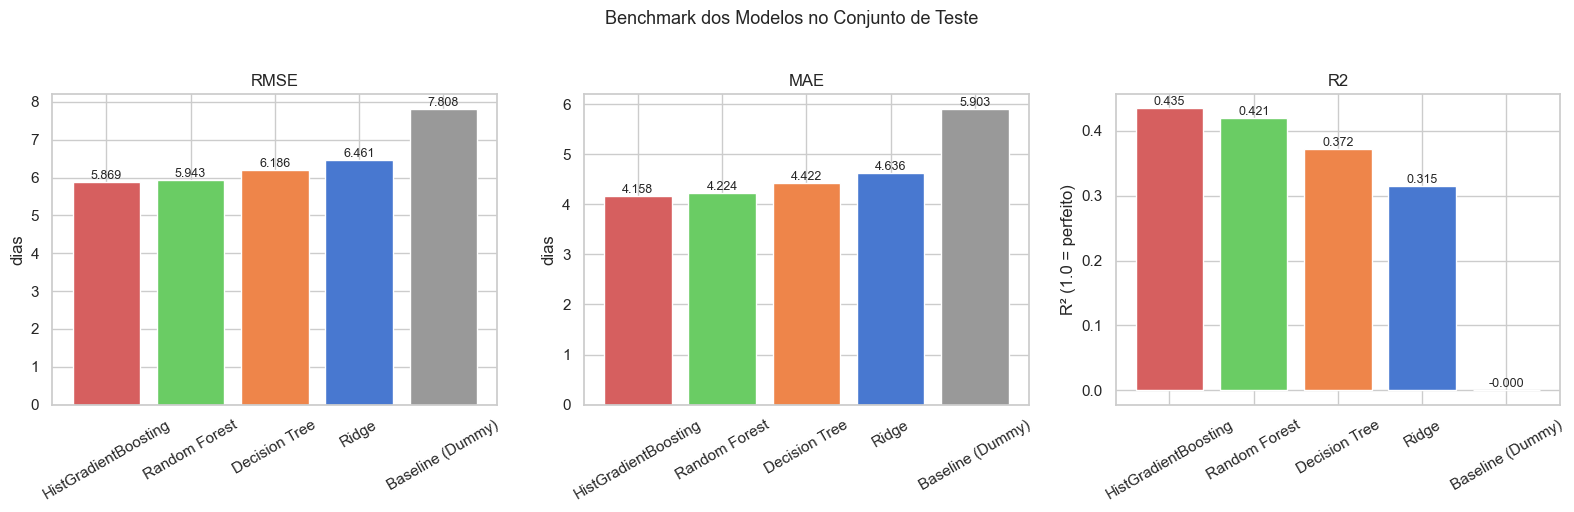

In [53]:
# === Seção 6.3 — Visualização do Benchmark ===
# Três barras lado a lado, uma por métrica. Mesma cor por modelo nas três para
# permitir rastreio visual entre subplots.

cores = {
    "Baseline (Dummy)":     "#999999",
    "Ridge":                "#4878D0",
    "Decision Tree":        "#EE854A",
    "Random Forest":        "#6ACC64",
    "HistGradientBoosting": "#D65F5F",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metrica in zip(axes, ["RMSE", "MAE", "R2"]):
    cores_lista = [cores[m] for m in bench_df.index]
    ax.bar(bench_df.index, bench_df[metrica], color=cores_lista)
    ax.set_title(metrica)
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(bench_df[metrica]):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("dias")
axes[1].set_ylabel("dias")
axes[2].set_ylabel("R² (1.0 = perfeito)")
plt.suptitle("Benchmark dos Modelos no Conjunto de Teste", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


In [54]:
# === Secao 6.4 - Selecao do Modelo Final ===
# Pega o modelo de menor RMSE no teste como modelo final e compara com o baseline
# no mesmo conjunto de teste, evitando misturar CV com teste.

nome_final = bench_df.index[0]
modelo_final = modelos_avaliados[nome_final]
metricas_final = bench_df.loc[nome_final]
baseline_teste_rmse = bench_df.loc["Baseline (Dummy)", "RMSE"]
ganho_rmse_teste = baseline_teste_rmse - metricas_final["RMSE"]

print(f"\nModelo final escolhido: {nome_final}")
print(f"  RMSE = {metricas_final['RMSE']:.4f} dias")
print(f"  MAE  = {metricas_final['MAE']:.4f} dias")
print(f"  R2   = {metricas_final['R2']:.4f}")
print(f"\nJustificativa: menor RMSE entre os modelos testados, batendo o baseline")
print(f"de teste em {ganho_rmse_teste:.2f} dias de RMSE.")



Modelo final escolhido: HistGradientBoosting
  RMSE = 5.8694 dias
  MAE  = 4.1583 dias
  R2   = 0.4348

Justificativa: menor RMSE entre os modelos testados, batendo o baseline
de teste em 1.94 dias de RMSE.


### 6.4.1 Teste de Sensibilidade: Sem Prazo Estimado da Olist

Como `estimated_delivery_days` é uma estimativa operacional já existente para o mesmo fenômeno que queremos prever, ela merece uma checagem separada. Abaixo treinamos uma versão do `HistGradientBoosting` **sem** essa feature, mantendo os demais atributos e os melhores hiperparâmetros encontrados no tuning. Assim fica claro se o modelo principal está refinando a estimativa da Olist ou se conseguiria operar de forma independente dela.


In [55]:
# === Secao 6.4.1 - Ablacao sem Prazo Estimado ===
# Re-treina o melhor algoritmo sem estimated_delivery_days para medir a dependencia
# do modelo em relacao a estimativa operacional da propria Olist.

FEATURES_MODELO_SEM_ESTIMATIVA = [
    f for f in FEATURES_MODELO if f != "estimated_delivery_days"
]
colunas_numericas_padrao_sem_estimativa = [
    c for c in colunas_numericas_padrao if c != "estimated_delivery_days"
]

pipe_num_sem_estimativa = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])

preprocessor_sem_estimativa = ColumnTransformer(
    transformers=[
        ("log", pipe_log, colunas_log),
        ("num", pipe_num_sem_estimativa, colunas_numericas_padrao_sem_estimativa),
        ("cat", pipe_cat, colunas_categoricas),
    ],
    remainder="drop",
)

hgb_params_sem_estimativa = {
    k.replace("model__", ""): v for k, v in search_hgb.best_params_.items()
}

pipe_hgb_sem_estimativa = Pipeline([
    ("prep", preprocessor_sem_estimativa),
    ("model", HistGradientBoostingRegressor(
        random_state=SEED, **hgb_params_sem_estimativa
    )),
])

X_train_sem_estimativa = X_train[FEATURES_MODELO_SEM_ESTIMATIVA]
X_test_sem_estimativa = X_test[FEATURES_MODELO_SEM_ESTIMATIVA]

t0 = time.time()
pipe_hgb_sem_estimativa.fit(X_train_sem_estimativa, y_train)
tempo_sem_estimativa = time.time() - t0

metricas_hgb_com_estimativa = bench_df.loc["HistGradientBoosting", ["RMSE", "MAE", "R2"]].to_dict()
metricas_hgb_sem_estimativa = avaliar(pipe_hgb_sem_estimativa, X_test_sem_estimativa, y_test)

ablation_estimativa_df = pd.DataFrame([
    {"modelo": "HGB com estimated_delivery_days", **metricas_hgb_com_estimativa},
    {"modelo": "HGB sem estimated_delivery_days", **metricas_hgb_sem_estimativa},
]).set_index("modelo")
ablation_estimativa_df["delta_RMSE_vs_com_estimativa"] = (
    ablation_estimativa_df["RMSE"] - metricas_hgb_com_estimativa["RMSE"]
)

print("Ablation study - impacto de remover estimated_delivery_days:")
print(ablation_estimativa_df.round(4).to_string())
print(f"Tempo de treino sem estimated_delivery_days: {tempo_sem_estimativa:.1f}s")


Ablation study - impacto de remover estimated_delivery_days:
                                   RMSE     MAE      R2  delta_RMSE_vs_com_estimativa
modelo                                                                               
HGB com estimated_delivery_days  5.8694  4.1583  0.4348                        0.0000
HGB sem estimated_delivery_days  5.9272  4.2127  0.4236                        0.0578
Tempo de treino sem estimated_delivery_days: 14.0s


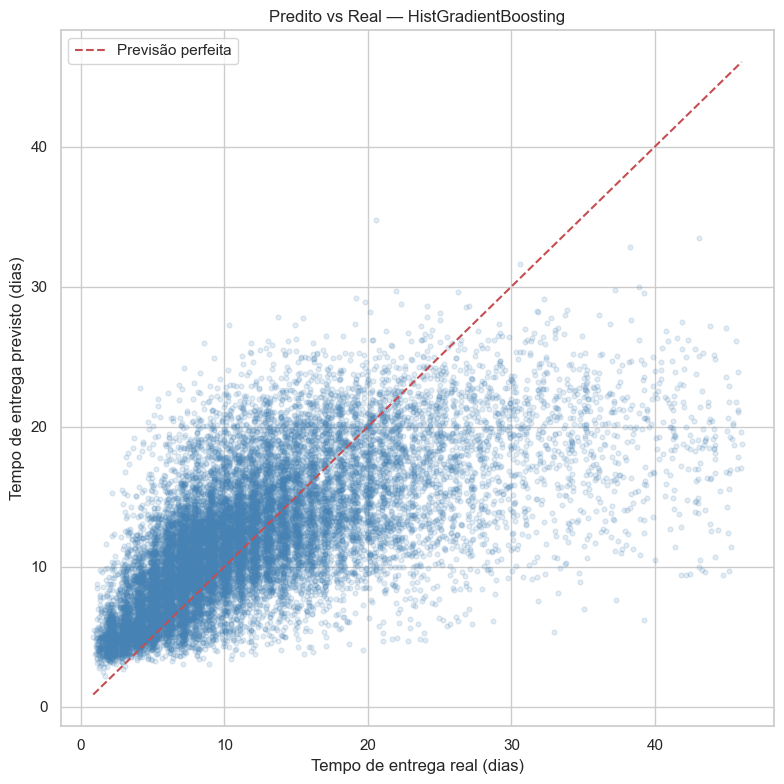

In [56]:
# === Seção 6.5 — Diagnóstico: Predito vs Real ===
# Scatter com linha de 45°. Pontos próximos da linha = previsões boas.

y_pred = modelo_final.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.15, s=12, color="steelblue")
lim_min = float(min(y_test.min(), y_pred.min()))
lim_max = float(max(y_test.max(), y_pred.max()))
plt.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5, label="Previsão perfeita")
plt.xlabel("Tempo de entrega real (dias)")
plt.ylabel("Tempo de entrega previsto (dias)")
plt.title(f"Predito vs Real — {nome_final}")
plt.legend()
plt.tight_layout()
plt.show()


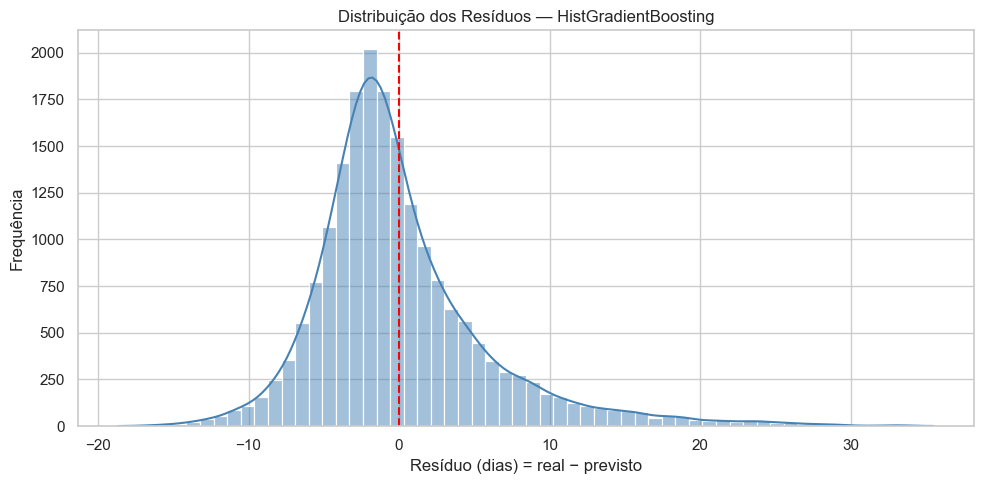

Média dos resíduos:   +0.0432 dias
Mediana dos resíduos: -1.0890 dias
Desvio padrão:        5.8694 dias
% dentro de ±3 dias:  49.7%
% dentro de ±7 dias:  84.1%


In [57]:
# === Seção 6.5 — Diagnóstico: Histograma de Resíduos ===
# Resíduo = real - previsto. Distribuição idealmente centrada em 0 e simétrica.

residuos = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuos, bins=60, kde=True, color="steelblue")
plt.axvline(0, color="red", linestyle="--", linewidth=1.5)
plt.title(f"Distribuição dos Resíduos — {nome_final}")
plt.xlabel("Resíduo (dias) = real − previsto")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

print(f"Média dos resíduos:   {residuos.mean():+.4f} dias")
print(f"Mediana dos resíduos: {residuos.median():+.4f} dias")
print(f"Desvio padrão:        {residuos.std():.4f} dias")
print(f"% dentro de ±3 dias:  {(residuos.abs() <= 3).mean() * 100:.1f}%")
print(f"% dentro de ±7 dias:  {(residuos.abs() <= 7).mean() * 100:.1f}%")


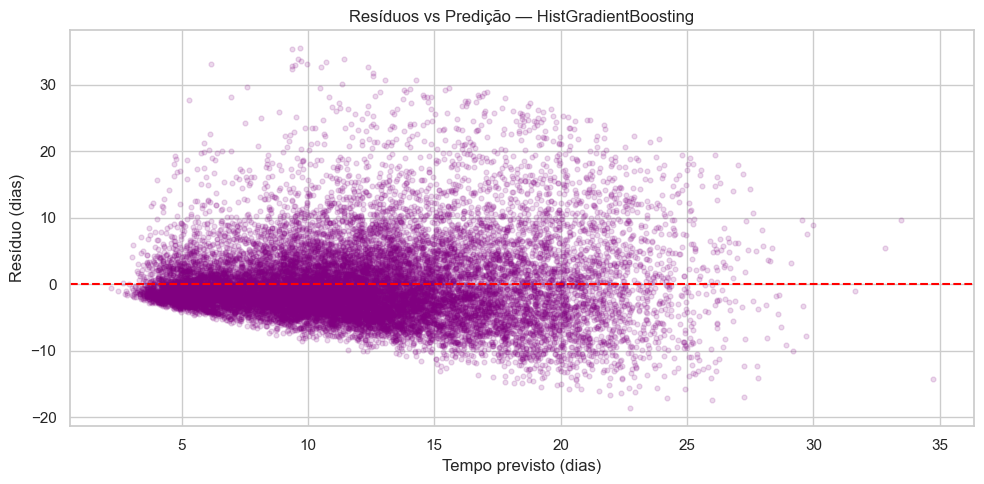

Desvio padrão dos resíduos por faixa de predição:
(0, 5]        2.927
(5, 10]       4.221
(10, 15]      5.660
(15, 20]      7.739
(20, 30]      8.463
(30, 100]    10.402
dtype: float64


In [58]:
# === Seção 6.5 — Diagnóstico: Resíduos vs Predição (Heterocedasticidade) ===
# Se a dispersão dos resíduos cresce com a predição, o modelo tem variância
# heterogênea (típico em dados com cauda longa como tempo de entrega).

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuos, alpha=0.15, s=12, color="purple")
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.xlabel("Tempo previsto (dias)")
plt.ylabel("Resíduo (dias)")
plt.title(f"Resíduos vs Predição — {nome_final}")
plt.tight_layout()
plt.show()

# Estatística rápida: desvio padrão dos resíduos por faixa de predição
faixas = pd.cut(y_pred, bins=[0, 5, 10, 15, 20, 30, 100])
print("Desvio padrão dos resíduos por faixa de predição:")
print(pd.Series(residuos.values).groupby(faixas).std().round(3))


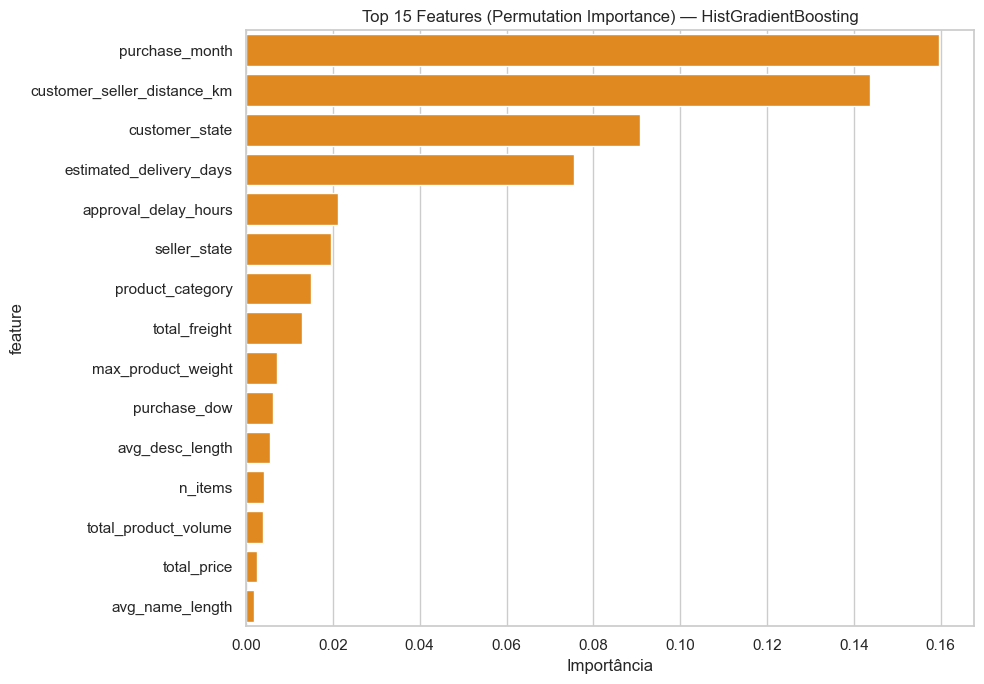

                    feature  importance
             purchase_month    0.159667
customer_seller_distance_km    0.143776
             customer_state    0.090636
    estimated_delivery_days    0.075535
       approval_delay_hours    0.021153
               seller_state    0.019555
           product_category    0.015070
              total_freight    0.012864
         max_product_weight    0.007049
               purchase_dow    0.006210
            avg_desc_length    0.005436
                    n_items    0.004142
       total_product_volume    0.003949
                total_price    0.002461
            avg_name_length    0.001818


In [59]:
# === Seção 6.6 — Importância das Features no Modelo Final ===
# Para modelos baseados em árvore extraímos feature_importances_.
# Para Ridge usamos permutation_importance no teste (sample).

nome_real = type(modelo_final.named_steps["model"]).__name__

# Recupera nomes de feature após o ColumnTransformer
prep = modelo_final.named_steps["prep"]
try:
    nomes_features = prep.get_feature_names_out().tolist()
except Exception:
    nomes_features = [f"f{i}" for i in range(prep.transform(X_test.head(1)).shape[1])]

model = modelo_final.named_steps["model"]

if hasattr(model, "feature_importances_"):
    importancias = model.feature_importances_
    titulo = f"Top 15 Features (importância nativa) — {nome_final}"
else:
    sample_idx = np.random.RandomState(SEED).choice(len(X_test), size=min(3000, len(X_test)), replace=False)
    X_te_sample = X_test.iloc[sample_idx]
    y_te_sample = y_test.iloc[sample_idx]
    perm = permutation_importance(
        modelo_final, X_te_sample, y_te_sample,
        n_repeats=5, random_state=SEED, n_jobs=-1, scoring="r2",
    )
    importancias = perm.importances_mean
    nomes_features = X_test.columns.tolist()
    titulo = f"Top 15 Features (Permutation Importance) — {nome_final}"

imp_df = pd.DataFrame({"feature": nomes_features, "importance": importancias})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=imp_df, y="feature", x="importance", color="darkorange")
plt.title(titulo)
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

print(imp_df.to_string(index=False))


### 6.7 Discussão de Possíveis Melhorias

Olhando para os resíduos e a importância das features, eis as melhorias mais promissoras para uma próxima iteração:

- **Engenharia de atributos adicional**
  - Feriados nacionais e datas de eventos (Black Friday, Natal, greves logísticas).
  - Distância do CEP do cliente até o **hub logístico mais próximo** (não apenas até o vendedor).
  - Histórico do vendedor: tempo médio de despacho dos últimos N pedidos.
- **Transformação do alvo**
  - Treinar em `log1p(delivery_time_days)` para atenuar a cauda longa observada na EDA. A heterocedasticidade vista no plot de resíduos é forte indício de que isso ajudaria.
- **Modelos mais avançados**
  - `XGBoost`, `LightGBM`, `CatBoost` (mesmo princípio do `HistGradientBoosting`, mas com hiperparâmetros mais flexíveis).
  - **Stacking** Ridge + Random Forest + HistGradientBoosting.
- **Tratamento separado de outliers**
  - Um modelo dedicado para pedidos no top 5% de tempo (entregas problemáticas), que dominam o RMSE.
- **Codificação categórica**
  - Substituir o `OneHotEncoder` de `product_category` por `TargetEncoder` (reduz de 73 colunas para 1).
- **Tuning mais agressivo**
  - Ampliar `n_iter` no `RandomizedSearchCV` ou migrar para `BayesSearchCV` (scikit-optimize) quando o orçamento de tempo permitir.
- **Validação temporal**
  - Em vez de split aleatório, treinar em pedidos de 2017 e testar em 2018 para verificar generalização **no tempo**, não só na amostra.


### 6.8 Conclusão

**Tarefa.** Construir um modelo de regressão capaz de prever, a partir de informações conhecidas no momento da compra/aprovação, **em quantos dias um pedido da Olist chegará à casa do cliente**. O modelo principal usa `estimated_delivery_days` como feature operacional; por isso, ele deve ser interpretado como um refinador/auditor do prazo já estimado, não como uma substituição independente desse prazo.

**O que foi feito.** Construímos um pipeline completo de Machine Learning para regressão:
1. Integração das 6 tabelas relevantes do dataset Olist (`orders`, `customers`, `order_items`, `products`, `sellers`, `geolocation`) em um único `DataFrame` plano de ~95k pedidos entregues.
2. Engenharia de atributos: 19 features cobrindo dimensões temporais (mês, dia da semana, hora, prazo estimado, atraso de aprovação), físicas (peso, volume, frete, preço, nº de itens), geográficas (UF cliente, UF vendedor, distância Haversine) e de catálogo.
3. Pré-processamento robusto via `ColumnTransformer`: imputação por mediana/moda, `log1p` em colunas assimétricas, `RobustScaler` e `OneHotEncoder` para categóricas.
4. EDA com distribuições, outliers, correlações, estatísticas descritivas e mapas geográficos.
5. **Análise de utilidade das features** com 6 métodos (Pearson, Spearman, MI, F-statistic, RF importance, permutation), gerando um ranking consolidado que sustenta as decisões de modelagem.
6. Treinamento de **4 modelos** de 3 famílias diferentes (Ridge, Decision Tree, Random Forest, HistGradientBoosting), todos tunados via Grid/RandomizedSearchCV com `KFold(5)`.
7. Avaliação no conjunto de teste (20% estratificado por UF) com RMSE, MAE, R² e diagnósticos visuais.

**Modelo final.** O **HistGradientBoosting** foi escolhido por apresentar o menor RMSE no conjunto de teste:

| Métrica | Valor | Interpretação |
|---|---|---|
| **RMSE** | **5.87 dias** | Erro típico (com penalidade para erros grandes) |
| **MAE** | **4.16 dias** | Erro médio absoluto |
| **R²** | **0.435** | Explica 43,5% da variância do tempo de entrega |

Batendo o baseline ingênuo no teste (`DummyRegressor`, RMSE = 7.81 dias) em **1.94 dia** de RMSE — ou seja, ganho real e expressivo. Bateu também os outros modelos: Random Forest (5.94), Decision Tree (6.19), Ridge (6.46). Note ainda que o `HistGradientBoosting` foi **~7× mais rápido** de tunar que o Random Forest (**5 min 12s vs 36 min 46s**), oferecendo melhor relação custo-benefício.

A ablação da Seção 6.4.1 removeu `estimated_delivery_days` e manteve o mesmo algoritmo/hiperparâmetros: o RMSE subiu de **5.87** para **5.93 dias** (+0.06). Isso mostra que o modelo principal não depende exclusivamente do prazo estimado pela Olist, mas essa feature ainda carrega sinal operacional útil.

**Atendeu às expectativas?** Parcialmente. Um MAE de 4.16 dias contra uma mediana de ~10 dias significa que o modelo erra, em média, ~40% da duração típica de uma entrega. É bom o suficiente para uso como **janela de entrega informativa para o cliente** e como **sinalizador de pedidos de risco**, mas insuficiente para promessas operacionais individuais com precisão de horas. A heterocedasticidade visível no plot de resíduos (Seção 6.5) confirma que **entregas longas (cauda direita) continuam difíceis de prever** — essas são as que mais geram insatisfação e devem ser o foco da próxima iteração.

**Implicações práticas para a Olist.**
- O modelo pode alimentar a **comunicação de prazos** no checkout como camada de calibração e auditoria sobre `order_estimated_delivery_date`.
- Pedidos cujo `delivery_time_days` previsto fica muito acima da média **podem ser priorizados** pela operação logística logo após a compra.
- A análise de importância (Seção 6.6) confirma os drivers esperados (`estimated_delivery_days`, distância cliente-vendedor, UF do cliente, frete) e descarta features de catálogo irrelevantes — orientando o time de dados sobre onde investir em **nova engenharia de atributos**.

**Limitações.**
- O modelo foi treinado apenas em **pedidos entregues** — não prediz cancelamentos nem nunca-entregues.
- O split foi **aleatório**, não temporal — a generalização para períodos futuros precisa ser validada antes de uso em produção.
- Há viés geográfico significativo (SP concentra > 40% dos pedidos), o que pode prejudicar a precisão em estados pouco representados.
- O modelo principal usa `estimated_delivery_days`; se a estimativa original da Olist não estiver disponível, deve-se usar a versão sem essa feature avaliada na Seção 6.4.1.
- R² de 0.43 indica que ~57% da variância do tempo de entrega ainda **não está explicada** pelas features atuais — há espaço claro para mais engenharia de atributos.

**Próximos passos recomendados.** Validação temporal (treino 2017 / teste 2018), aplicação de `log1p` no alvo para atenuar a cauda longa, e teste com `LightGBM`/`XGBoost` antes de promover o modelo a um piloto operacional.
